In [1]:
import xarray as xr
import numpy as np
import pandas as pd
from scipy import stats

# ── 1. Load cleaned SPI Index ───────────────────────────────────────────────
da = (
    xr.open_dataarray("/Users/coralieroland/ACI-Python/data/composites/precipitation_index.nc")
      .sel(time=slice("1961-01-01", None))
)

# ── 2. Collapse over 'step' if present (for SPI it's already 1-D) ─────────
if "step" in da.dims:
    da = da.mean(dim="step")

# Force load into memory
da = da.compute()

# ── 3. Convert to pandas Series and drop NaNs ──────────────────────────────
ser   = da.to_series().dropna()
n_tot = ser.size

# ── 4. Descriptive statistics ─────────────────────────────────────────────
desc  = ser.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
skew  = ser.skew()
kurt  = ser.kurtosis()

# ── 5. Event counts ────────────────────────────────────────────────────────
#  moderate: 1σ < |SPI| ≤ 2σ
n_mod_pos = ((ser > 1) & (ser <= 2)).sum()
n_mod_neg = ((ser < -1) & (ser >= -2)).sum()
n_mod     = n_mod_pos + n_mod_neg

#  extreme: |SPI| > 2σ
n_extreme = ((ser > 2) | (ser < -2)).sum()

# ── 6. Linear trend (OLS) ─────────────────────────────────────────────────
years      = ser.index.year + (ser.index.dayofyear - 1) / 365.25
slope, intercept, r, p, _ = stats.linregress(years, ser.values)

# ── 7. Print results ─────────────────────────────────────────────────────
print("\n📊 Descriptive statistics for SPI_index")
print(desc.to_string(float_format="%.3f"))
print(f"skewness : {skew:6.3f}")
print(f"kurtosis : {kurt:6.3f}")

print("\n⚠️  Moderate‐event frequency (1σ < |SPI| ≤ 2σ)")
print(f"{n_mod:3d} / {n_tot}   ({n_mod/n_tot:5.1%})")

print("\n🚨  Extreme‐event frequency (|SPI| > 2σ)")
print(f"{n_extreme:3d} / {n_tot}   ({n_extreme/n_tot:5.1%})")

print("\n📈  Linear trend (OLS on standardized SPI)")
print(f"slope (per year)   : {slope: .4f}")
print(f"slope (per decade) : {slope*10: .4f}")
print(f"R²                 : {r**2: .3f}")
print(f"p-value            : {p: .3e}")


📊 Descriptive statistics for SPI_index
count   768.000
mean      0.074
std       0.850
min      -1.881
5%       -1.242
25%      -0.492
50%       0.016
75%       0.595
95%       1.519
max       4.648
skewness :  0.574
kurtosis :  1.420

⚠️  Moderate‐event frequency (1σ < |SPI| ≤ 2σ)
158 / 768   (20.6%)

🚨  Extreme‐event frequency (|SPI| > 2σ)
 12 / 768   ( 1.6%)

📈  Linear trend (OLS on standardized SPI)
slope (per year)   :  0.0053
slope (per decade) :  0.0526
R²                 :  0.013
p-value            :  1.494e-03


All (1961–2024): {'n': 768, 'mean': 0.07354479283094406, 'std': 0.8499181270599365, 'skew': 0.573703408241272, 'kurt': 1.4198474884033203, 'mod_freq': 158, 'ext_freq': 12}
Ref (1961–1990): {'n': 360, 'mean': -5.298190774993827e-09, 'std': 0.7762473821640015, 'skew': 0.3056594133377075, 'kurt': 0.1903080940246582, 'mod_freq': 66, 'ext_freq': 3}
Study (1991–2024): {'n': 408, 'mean': 0.13843725621700287, 'std': 0.9059813022613525, 'skew': 0.6678382158279419, 'kurt': 1.7705602645874023, 'mod_freq': 92, 'ext_freq': 9}


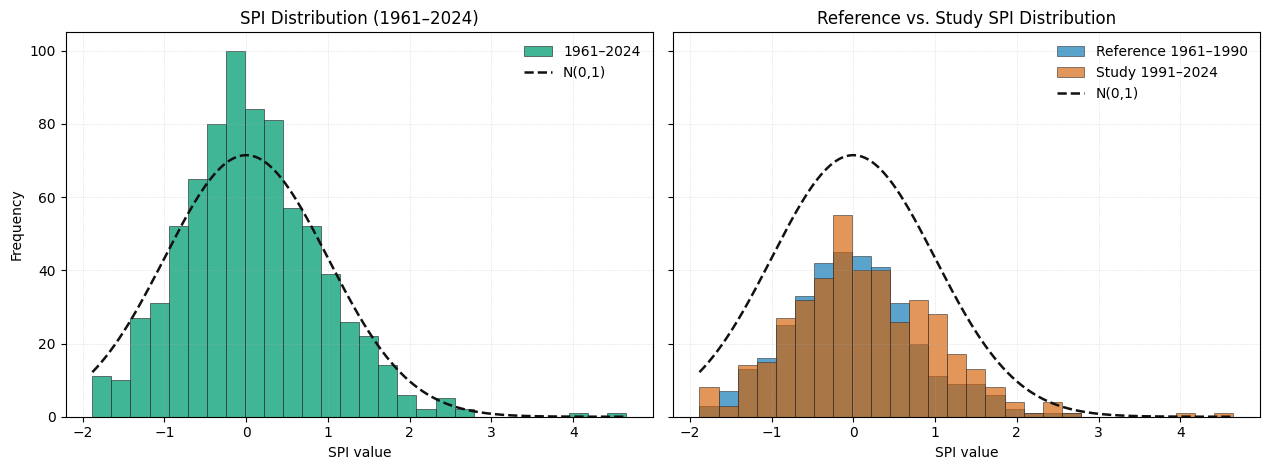

Plot saved as spi_histograms_side_by_side.png


In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# ── Paths & params ─────────────────────────────────────────────────────────
SPI_PATH   = "/Users/coralieroland/ACI-Python/data/composites/precipitation_index.nc"
REF_START  = "1961-01-01"
REF_END    = "1990-12-31"
STUDY_START= "1991-01-01"
STUDY_END  = "2024-12-31"
OUT_PNG    = "spi_histograms_side_by_side.png"

# ── 1) Load & build monthly series (use 'ME' to avoid the warning) ────────
da = xr.open_dataarray(SPI_PATH, chunks="auto").sortby("time")

# Collapse optional forecast step
if "step" in da.dims:
    da = da.mean("step", skipna=True, keep_attrs=True)

# Resample only if not already monthly-end or month-start
freq = xr.infer_freq(da.time)
if freq not in ("ME", "MS"):
    da = da.resample(time="ME").mean()

# Slice to desired window and compute (if dask-backed)
spi = da.sel(time=slice(REF_START, STUDY_END)).astype("float32").compute()

# Convert to pandas (fast & simple for slicing) and drop non-finite
ser = spi.to_series()
ser = ser[np.isfinite(ser.values)]

# Split periods
ser_ref   = ser.loc[REF_START:REF_END]
ser_study = ser.loc[STUDY_START:STUDY_END]
if ser_ref.empty or ser_study.empty:
    raise ValueError(f"Empty period(s): ref={ser_ref.empty}, study={ser_study.empty}")

# ── 2) Common bins (Freedman–Diaconis) + normal overlay scale ─────────────
# Use combined series for stable, comparable bins
bin_edges = np.histogram_bin_edges(ser.values, bins="fd")
# guarantee a reasonable number of bins (fallback 30 if FD degenerates)
if len(bin_edges) < 5:
    bin_edges = np.linspace(ser.min(), ser.max(), 31)

binw = np.diff(bin_edges)[0]
x    = np.linspace(bin_edges[0], bin_edges[-1], 600)

# Theoretical SPI ~ N(0,1) overlay, scaled to counts per bin
normal_counts = len(ser) * binw * stats.norm.pdf(x, loc=0.0, scale=1.0)

# ── 3) Quick distribution diagnostics (for the console) ───────────────────
def quick_stats(v):
    v = np.asarray(v)
    v = v[np.isfinite(v)]
    return dict(
        n=len(v),
        mean=float(np.mean(v)),
        std=float(np.std(v, ddof=1)),
        skew=float(stats.skew(v, bias=False)),
        kurt=float(stats.kurtosis(v, fisher=True, bias=False)),
        mod_freq=int(np.sum((np.abs(v) > 1.0) & (np.abs(v) <= 2.0))),
        ext_freq=int(np.sum(np.abs(v) > 2.0)),
    )

S_all   = quick_stats(ser.values)
S_ref   = quick_stats(ser_ref.values)
S_study = quick_stats(ser_study.values)

print("All (1961–2024):", S_all)
print("Ref (1961–1990):", S_ref)
print("Study (1991–2024):", S_study)

# ── 4) Plot (color-blind–safe palette) ─────────────────────────────────────
PALETTE = {
    "all":   "#009E73",  # bluish green
    "ref":   "#0072B2",  # blue
    "study": "#D55E00",  # vermilion
    "curve": "#111111",  # normal overlay line
    "edge":  "#2C2C2C",  # bar edge
}

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8), sharey=True)

# Left: full period
axes[0].hist(
    ser.values, bins=bin_edges,
    color=PALETTE["all"], alpha=0.75,
    edgecolor=PALETTE["edge"], linewidth=0.6,
    label="1961–2024"
)
axes[0].plot(
    x, normal_counts, color=PALETTE["curve"],
    ls="--", lw=1.8, label="N(0,1)"
)
axes[0].set_title("SPI Distribution (1961–2024)")
axes[0].set_xlabel("SPI value")
axes[0].set_ylabel("Frequency")
axes[0].grid(True, ls=":", lw=0.4, alpha=0.7)
axes[0].legend(frameon=False)

# Right: ref vs study (same bins)
axes[1].hist(
    ser_ref.values, bins=bin_edges,
    color=PALETTE["ref"], alpha=0.65,
    edgecolor=PALETTE["edge"], linewidth=0.6,
    label="Reference 1961–1990"
)
axes[1].hist(
    ser_study.values, bins=bin_edges,
    color=PALETTE["study"], alpha=0.65,
    edgecolor=PALETTE["edge"], linewidth=0.6,
    label="Study 1991–2024"
)
axes[1].plot(
    x, normal_counts, color=PALETTE["curve"],
    ls="--", lw=1.8, label="N(0,1)"
)
axes[1].set_title("Reference vs. Study SPI Distribution")
axes[1].set_xlabel("SPI value")
axes[1].grid(True, ls=":", lw=0.4, alpha=0.7)
axes[1].legend(frameon=False)

plt.tight_layout()
fig.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
plt.show()
print(f"Plot saved as {OUT_PNG}")



SPI months: 768  |  ≤1σ: 498 (64.8%)  1–2σ: 221 (28.8%)  >2σ: 49 (6.4%)


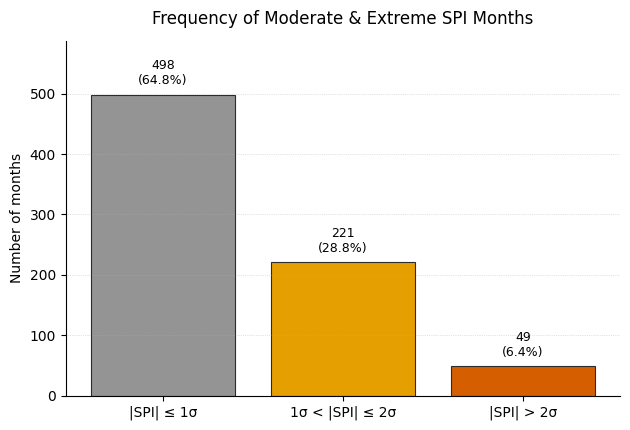

Plot saved as spi_frequency_3bars.png


In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

# ── Config ─────────────────────────────────────────────────────────────────
INDEX_PATH = "ACI-Python/data/composites/precipitation_index.nc"  # any 1-D monthly index works
START_DATE = "1961-01-01"
END_DATE   = None  # keep None to go to the end
LABEL      = "SPI"  # used in title/filename
OUT_PNG    = f"{LABEL.lower()}_frequency_3bars.png"

# Okabe–Ito colors (color-blind safe)
C_LE1   = "#949494"  # gray
C_1TO2  = "#E69F00"  # orange
C_GT2   = "#D55E00"  # vermilion
C_EDGE  = "#2C2C2C"

# ── 1) Load monthly series (robust & dask-friendly) ───────────────────────
da = xr.open_dataarray(INDEX_PATH, chunks="auto").sortby("time")

# collapse optional 'step'
if "step" in da.dims:
    da = da.mean("step", skipna=True, keep_attrs=True)

# resample to month-end only if not already monthly
freq = xr.infer_freq(da.time)
if freq not in ("ME", "MS"):
    da = da.resample(time="ME").mean()

# make month-end if it was month-start
if freq == "MS":
    da = da.resample(time="ME").mean()

# trim and compute once (float32 to save RAM)
da = da.sel(time=slice(START_DATE, END_DATE)).astype("float32").compute()

# ── 2) Counts (fully vectorized) ──────────────────────────────────────────
vals = da.to_series().to_numpy()
vals = vals[np.isfinite(vals)]
n_tot = vals.size

abs_v = np.abs(vals)
count_le1 = int(np.count_nonzero(abs_v <= 1.0))                       # |x| ≤ 1
count_1_2 = int(np.count_nonzero((abs_v > 1.0) & (abs_v <= 2.0)))     # 1 < |x| ≤ 2
count_gt2 = int(np.count_nonzero(abs_v > 2.0))                         # |x| > 2

counts   = np.array([count_le1, count_1_2, count_gt2], dtype=int)
labels   = [f"|{LABEL}| ≤ 1σ", f"1σ < |{LABEL}| ≤ 2σ", f"|{LABEL}| > 2σ"]
percents = counts / max(n_tot, 1) * 100.0

# console summary
print(
    f"{LABEL} months: {n_tot}  |  ≤1σ: {count_le1} ({percents[0]:.1f}%)"
    f"  1–2σ: {count_1_2} ({percents[1]:.1f}%)  >2σ: {count_gt2} ({percents[2]:.1f}%)"
)

# ── 3) Plot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6.4, 4.4))
bars = ax.bar(
    labels, counts,
    color=[C_LE1, C_1TO2, C_GT2],
    edgecolor=C_EDGE, linewidth=0.8
)

ax.set_ylabel("Number of months")
ax.set_title(f"Frequency of Moderate & Extreme {LABEL} Months", pad=12)

# nicer axes
ax.grid(True, axis="y", ls=":", lw=0.5, alpha=0.7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

max_count = counts.max() if n_tot else 1
ax.set_ylim(0, max_count * 1.18)

# annotate bars (count + %)
for bar, pct in zip(bars, percents):
    y = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2, y + max_count * 0.025,
        f"{y:,}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=9
    )

plt.tight_layout()
fig.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
plt.show()
print(f"Plot saved as {OUT_PNG}")


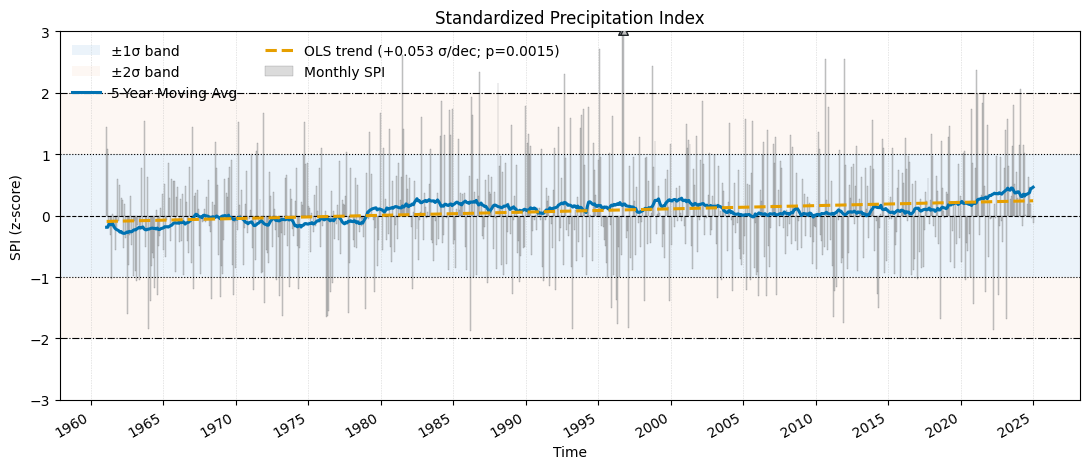

Plot saved as spi_timeseries_plot.png
Slope: 0.00526 σ/yr (0.053 σ/dec), 95% CI [0.00202, 0.00850], R²=0.013, p=0.001494, n=768, clipped_hi=2, clipped_lo=0, ylim=±3


In [3]:
# spi_timeseries_optionA.py
# SPI timeseries with ±1σ/±2σ shaded bands and legend proxies (Option A).

import xarray as xr
import matplotlib.dates as mdates
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch
from scipy import stats
from scipy.stats import t as tdist

# ── 0) Load cleaned SPI ───────────────────────────────────────────────────
da = xr.open_dataarray("/Users/coralieroland/ACI-Python/data/composites/precipitation_index.nc")

# ── 1) Build true 1-D monthly SPI series ─────────────────────────────────
if "step" in da.dims:
    da = da.mean(dim="step")  # collapse forecast steps if present

da = da.sel(time=slice("1961-01-01", None))

spi_series = da.to_series().dropna()
spi_series.index = (
    pd.to_datetime(spi_series.index)
      .to_period("M")
      .to_timestamp("M")
)

# ── 2) Rolling mean & OLS trend on the monthly series ─────────────────────
rolling_60 = spi_series.rolling(60, center=True, min_periods=30).mean()

# fractional calendar year for regression
years = spi_series.index.year + (spi_series.index.dayofyear - 1) / 365.2425
y = spi_series.values

slope, intercept, r, p, stderr = stats.linregress(years, y)
trend_series = pd.Series(intercept + slope * years, index=spi_series.index)

# 95% CI for slope (classic OLS; assumes iid errors)
n = len(y)
df = n - 2
tcrit = tdist.ppf(0.975, df) if df > 0 else np.nan
slope_ci = (slope - tcrit * stderr, slope + tcrit * stderr)

# ── 3) Plot (Okabe–Ito palette, σ-bands, robust y-limits) ────────────────
C = {
    "bars":  "#BFBFBF",   # monthly bars
    "roll":  "#0072B2",   # 5-year MA (blue)
    "trend": "#E69F00",   # OLS trend (orange)
    "edge":  "#1F2428",
    "band1": "#C7DFF1",   # ±1σ band
    "band2": "#F8D9C7",   # slab between 1σ and 2σ (and sym.)
}

fig, ax = plt.subplots(figsize=(11, 4.8))

# Robust symmetric y-limits
q = np.nanquantile(np.abs(spi_series.values), 0.995)
ylim = max(3.0, float(np.ceil(q * 10) / 10))
ax.set_ylim(-ylim, ylim)
ax.set_yticks(np.arange(-int(np.floor(ylim)), int(np.floor(ylim)) + 1))

# σ-bands (drawn behind everything)
ax.axhspan(-1,  1, facecolor=C["band1"], alpha=0.35, zorder=0)
ax.axhspan( 1,  2, facecolor=C["band2"], alpha=0.20, zorder=0)
ax.axhspan(-2, -1, facecolor=C["band2"], alpha=0.20, zorder=0)

# Monthly bars
ax.bar(
    spi_series.index, spi_series.values,
    width=25, color=C["bars"], edgecolor=C["edge"], linewidth=0.2,
    alpha=0.55, align="center", zorder=1, label="Monthly SPI"
)

# Mark values clipped by y-limit
hi = spi_series[spi_series >  ylim]
lo = spi_series[spi_series < -ylim]
if len(hi):
    ax.scatter(hi.index, np.full(len(hi),  ylim), marker="^", s=30,
               facecolor=C["bars"], edgecolor=C["edge"], zorder=4)
if len(lo):
    ax.scatter(lo.index, np.full(len(lo), -ylim), marker="v", s=30,
               facecolor=C["bars"], edgecolor=C["edge"], zorder=4)

# Rolling mean & OLS trend
ax.plot(rolling_60.index, rolling_60.values, color=C["roll"], lw=2.2, label="5-Year Moving Avg", zorder=3)
ax.plot(trend_series.index, trend_series.values, color=C["trend"], ls="--", lw=2.2,
        label=f"OLS trend ({slope*10:+.3f} σ/dec; p={p:.4f})", zorder=3)

# Reference lines
for yref, ls in [(0, "--"), (1, ":"), (-1, ":"), (2, "-."), (-2, "-.")]:
    ax.axhline(yref, color="black", lw=0.8, ls=ls, zorder=2)

ax.set_title("Standardized Precipitation Index")
ax.set_xlabel("Time")
ax.set_ylabel("SPI (z-score)")
ax.grid(True, ls=":", lw=0.45, alpha=0.75)

# ── Legend with proxy patches for σ-bands (Option A) ──────────────────────
band1_leg = Patch(facecolor=C["band1"], alpha=0.35, edgecolor="none", label="±1σ band")
band2_leg = Patch(facecolor=C["band2"], alpha=0.20, edgecolor="none", label="±2σ band")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=[band1_leg, band2_leg] + handles, loc="upper left", ncols=2, frameon=False)

# Time axis formatting
ax.xaxis.set_major_locator(mdates.YearLocator(base=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.autofmt_xdate()

plt.tight_layout()
fig.savefig("spi_timeseries_plot.png", dpi=300, bbox_inches="tight")
plt.show()
print("Plot saved as spi_timeseries_plot.png")

# Console summary
print(
    f"Slope: {slope:.5f} σ/yr ({slope*10:.3f} σ/dec), "
    f"95% CI [{slope_ci[0]:.5f}, {slope_ci[1]:.5f}], "
    f"R²={r*r:.3f}, p={p:.4g}, n={n}, "
    f"clipped_hi={len(hi)}, clipped_lo={len(lo)}, ylim=±{ylim:g}"
)


In [4]:
import xarray as xr
import numpy as np
import pandas as pd
from scipy import stats

# ── 1. Load cleaned t90 Index ───────────────────────────────────────────────
da = (
    xr.open_dataarray("/Users/coralieroland/ACI-Python/data/composites/t90_index.nc")
      .sel(time=slice("1961-01-01", None))
)

# ── 2. Collapse over 'step' if present (for t90 it's already 1-D) ─────────
if "step" in da.dims:
    da = da.mean(dim="step")

# Force load into memory
da = da.compute()

# ── 3. Convert to pandas Series and drop NaNs ──────────────────────────────
ser   = da.to_series().dropna()
n_tot = ser.size

# ── 4. Descriptive statistics ─────────────────────────────────────────────
desc  = ser.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
skew  = ser.skew()
kurt  = ser.kurtosis()

# ── 5. Event counts ────────────────────────────────────────────────────────
#  moderate: 1σ < |t90| ≤ 2σ
n_mod_pos = ((ser > 1) & (ser <= 2)).sum()
n_mod_neg = ((ser < -1) & (ser >= -2)).sum()
n_mod     = n_mod_pos + n_mod_neg

#  extreme: |t90| > 2σ
n_extreme = ((ser > 2) | (ser < -2)).sum()

# ── 6. Linear trend (OLS) ─────────────────────────────────────────────────
years      = ser.index.year + (ser.index.dayofyear - 1) / 365.25
slope, intercept, r, p, _ = stats.linregress(years, ser.values)

# ── 7. Print results ─────────────────────────────────────────────────────
print("\n📊 Descriptive statistics for t90_index")
print(desc.to_string(float_format="%.3f"))
print(f"skewness : {skew:6.3f}")
print(f"kurtosis : {kurt:6.3f}")

print("\n⚠️  Moderate‐event frequency (1σ < |t90| ≤ 2σ)")
print(f"{n_mod:3d} / {n_tot}   ({n_mod/n_tot:5.1%})")

print("\n🚨  Extreme‐event frequency (|t90| > 2σ)")
print(f"{n_extreme:3d} / {n_tot}   ({n_extreme/n_tot:5.1%})")

print("\n📈  Linear trend (OLS on standardized t90)")
print(f"slope (per year)   : {slope: .4f}")
print(f"slope (per decade) : {slope*10: .4f}")
print(f"R²                 : {r**2: .3f}")
print(f"p-value            : {p: .3e}")



📊 Descriptive statistics for t90_index
count   634.000
mean      0.376
std       1.145
min      -2.294
5%       -1.246
25%      -0.515
50%       0.290
75%       1.153
95%       2.355
max       4.382
skewness :  0.445
kurtosis : -0.114

⚠️  Moderate‐event frequency (1σ < |t90| ≤ 2σ)
213 / 634   (33.6%)

🚨  Extreme‐event frequency (|t90| > 2σ)
 52 / 634   ( 8.2%)

📈  Linear trend (OLS on standardized t90)
slope (per year)   :  0.0210
slope (per decade) :  0.2098
R²                 :  0.116
p-value            :  1.157e-18


In [5]:
import xarray as xr
import numpy as np
import pandas as pd
from scipy import stats

# ── 1. Load cleaned t10 Index ───────────────────────────────────────────────
da = (
    xr.open_dataarray("/Users/coralieroland/ACI-Python/data/composites/t10_index.nc")
      .sel(time=slice("1961-01-01", None))
)

# ── 2. Collapse over 'step' if present (for t10 it's already 1-D) ─────────
if "step" in da.dims:
    da = da.mean(dim="step")

# Force load into memory
da = da.compute()

# ── 3. Convert to pandas Series and drop NaNs ──────────────────────────────
ser   = da.to_series().dropna()
n_tot = ser.size

# ── 4. Descriptive statistics ─────────────────────────────────────────────
desc  = ser.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
skew  = ser.skew()
kurt  = ser.kurtosis()

# ── 5. Event counts ────────────────────────────────────────────────────────
#  moderate: 1σ < |t10| ≤ 2σ
n_mod_pos = ((ser > 1) & (ser <= 2)).sum()
n_mod_neg = ((ser < -1) & (ser >= -2)).sum()
n_mod     = n_mod_pos + n_mod_neg

#  extreme: |t10| > 2σ
n_extreme = ((ser > 2) | (ser < -2)).sum()

# ── 6. Linear trend (OLS) ─────────────────────────────────────────────────
years      = ser.index.year + (ser.index.dayofyear - 1) / 365.25
slope, intercept, r, p, _ = stats.linregress(years, ser.values)

# ── 7. Print results ─────────────────────────────────────────────────────
print("\n📊 Descriptive statistics for t10_index")
print(desc.to_string(float_format="%.3f"))
print(f"skewness : {skew:6.3f}")
print(f"kurtosis : {kurt:6.3f}")

print("\n⚠️  Moderate‐event frequency (1σ < |t10| ≤ 2σ)")
print(f"{n_mod:3d} / {n_tot}   ({n_mod/n_tot:5.1%})")

print("\n🚨  Extreme‐event frequency (|t10| > 2σ)")
print(f"{n_extreme:3d} / {n_tot}   ({n_extreme/n_tot:5.1%})")

print("\n📈  Linear trend (OLS on standardized t10)")
print(f"slope (per year)   : {slope: .4f}")
print(f"slope (per decade) : {slope*10: .4f}")
print(f"R²                 : {r**2: .3f}")
print(f"p-value            : {p: .3e}")



📊 Descriptive statistics for t10_index
count   634.000
mean     -0.303
std       0.968
min      -2.301
5%       -1.603
25%      -0.996
50%      -0.453
75%       0.231
95%       1.651
max       3.098
skewness :  0.772
kurtosis :  0.564

⚠️  Moderate‐event frequency (1σ < |t10| ≤ 2σ)
196 / 634   (30.9%)

🚨  Extreme‐event frequency (|t10| > 2σ)
 25 / 634   ( 3.9%)

📈  Linear trend (OLS on standardized t10)
slope (per year)   : -0.0175
slope (per decade) : -0.1748
R²                 :  0.113
p-value            :  3.687e-18


In [6]:
import xarray as xr
import numpy as np
import pandas as pd
from scipy import stats

# ── 1. Load cleaned Wind Index ───────────────────────────────────────────
da = (
    xr.open_dataarray("/Users/coralieroland/ACI-Python/data/composites/wind_index.nc")
      .sel(time=slice("1961-01-01", None))
)

# ── 2. Collapse over 'step' if present (usually not for saved index) ────
if "step" in da.dims:
    da = da.mean(dim="step")

# Force load into memory (resolve any dask laziness)
da = da.compute()

# ── 3. Convert to pandas Series and drop NaNs ────────────────────────────
ser   = da.to_series().dropna()
n_tot = ser.size

# ── 4. Descriptive statistics ───────────────────────────────────────────
desc  = ser.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
skew  = ser.skew()
kurt  = ser.kurtosis()

# ── 5. Event counts (z-score thresholds, since wind_index is standardized)
#  moderate: 1σ < |wind| ≤ 2σ
n_mod_pos = ((ser > 1) & (ser <= 2)).sum()
n_mod_neg = ((ser < -1) & (ser >= -2)).sum()
n_mod     = n_mod_pos + n_mod_neg

#  extreme: |wind| > 2σ
n_extreme = ((ser > 2) | (ser < -2)).sum()

# ── 6. Linear trend (OLS) ───────────────────────────────────────────────
years = ser.index.year + (ser.index.dayofyear - 1) / 365.25
slope, intercept, r, p, _ = stats.linregress(years, ser.values)

# ── 7. Print results ────────────────────────────────────────────────────
print("\n📊 Descriptive statistics for wind_index")
print(desc.to_string(float_format="%.3f"))
print(f"skewness : {skew:6.3f}")
print(f"kurtosis : {kurt:6.3f}")

print("\n⚠️  Moderate‐event frequency (1σ < |wind| ≤ 2σ)")
print(f"{n_mod:3d} / {n_tot}   ({n_mod/n_tot:5.1%})")

print("\n🚨  Extreme‐event frequency (|wind| > 2σ)")
print(f"{n_extreme:3d} / {n_tot}   ({n_extreme/n_tot:5.1%})")

print("\n📈  Linear trend (OLS on standardized wind_index)")
print(f"slope (per year)   : {slope: .4f}")
print(f"slope (per decade) : {slope*10: .4f}")
print(f"R²                 : {r**2: .3f}")
print(f"p-value            : {p: .3e}")



📊 Descriptive statistics for wind_index
count   768.000
mean      0.049
std       0.980
min      -1.612
5%       -1.199
25%      -0.685
50%      -0.119
75%       0.610
95%       1.955
max       4.027
skewness :  0.927
kurtosis :  0.883

⚠️  Moderate‐event frequency (1σ < |wind| ≤ 2σ)
182 / 768   (23.7%)

🚨  Extreme‐event frequency (|wind| > 2σ)
 35 / 768   ( 4.6%)

📈  Linear trend (OLS on standardized wind_index)
slope (per year)   :  0.0019
slope (per decade) :  0.0186
R²                 :  0.001
p-value            :  3.317e-01


In [7]:
import xarray as xr
import numpy as np
import pandas as pd
from scipy import stats

# ── 1) Load saved Sea‑Level Index ─────────────────────────────────────────
# Script 1 saved a Dataset with one variable per gauge (column).
ds = xr.open_dataset("/Users/coralieroland/ACI-Python/data/composites/sealevel_index.nc")

# Collapse gauges → single monthly series
# (to_array gives a DataArray with dims ("variable","time"))
da = ds.to_array(name="sealevel_index").mean(dim="variable")

# Keep full period (1961–… as available)
da = da.sel(time=slice("1961-01-01", None))

# If a 'step' dim exists (unlikely here), collapse it
if "step" in da.dims:
    da = da.mean(dim="step")

# Force load (resolve any dask laziness)
da = da.compute()

# ── 2) Convert to pandas Series and drop NaNs ─────────────────────────────
ser   = da.to_series().dropna()
n_tot = ser.size

# ── 3) Descriptive statistics ────────────────────────────────────────────
desc  = ser.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
skew  = ser.skew()
kurt  = ser.kurtosis()

# ── 4) Event counts (z-score thresholds; index is standardized) ──────────
# moderate: 1σ < |z| ≤ 2σ
n_mod_pos = ((ser > 1) & (ser <= 2)).sum()
n_mod_neg = ((ser < -1) & (ser >= -2)).sum()
n_mod     = n_mod_pos + n_mod_neg

# extreme: |z| > 2σ
n_extreme = ((ser > 2) | (ser < -2)).sum()

# ── 5) Linear trend (OLS) ────────────────────────────────────────────────
years = ser.index.year + (ser.index.dayofyear - 1) / 365.25
slope, intercept, r, p, _ = stats.linregress(years, ser.values)

# ── 6) Print results ─────────────────────────────────────────────────────
print("\n📊 Descriptive statistics for sealevel_index (country-mean series)")
print(desc.to_string(float_format="%.3f"))
print(f"skewness : {skew:6.3f}")
print(f"kurtosis : {kurt:6.3f}")

print("\n⚠️  Moderate-event frequency (1σ < |z| ≤ 2σ)")
print(f"{n_mod:3d} / {n_tot}   ({n_mod/n_tot:5.1%})")

print("\n🚨  Extreme-event frequency (|z| > 2σ)")
print(f"{n_extreme:3d} / {n_tot}   ({n_extreme/n_tot:5.1%})")

print("\n📈  Linear trend (OLS on standardized sealevel_index)")
print(f"slope (per year)   : {slope: .4f}")
print(f"slope (per decade) : {slope*10: .4f}")
print(f"R²                 : {r**2: .3f}")
print(f"p-value            : {p: .3e}")



📊 Descriptive statistics for sealevel_index (country-mean series)
count   768.000
mean      0.784
std       1.290
min      -2.544
5%       -1.228
25%      -0.166
50%       0.804
75%       1.648
95%       2.939
max       5.379
skewness :  0.272
kurtosis :  0.107

⚠️  Moderate-event frequency (1σ < |z| ≤ 2σ)
266 / 768   (34.6%)

🚨  Extreme-event frequency (|z| > 2σ)
130 / 768   (16.9%)

📈  Linear trend (OLS on standardized sealevel_index)
slope (per year)   :  0.0480
slope (per decade) :  0.4798
R²                 :  0.473
p-value            :  1.462e-108


In [8]:
import xarray as xr
import numpy as np
import pandas as pd
from scipy import stats

# ── 1) Load saved Drought Index ───────────────────────────────────────────
# Script 1 saved a DataArray at this path
da = xr.open_dataarray("/Users/coralieroland/ACI-Python/data/composites/drought_index.nc")

# Keep study period (1961–… as available)
da = da.sel(time=slice("1961-01-01", None))

# Collapse 'step' if present
if "step" in da.dims:
    da = da.mean(dim="step")

# If any spatial/other dims remain, average them (keep only time)
other_dims = [d for d in da.dims if d != "time"]
if other_dims:
    da = da.mean(dim=other_dims)

# Force load (resolve dask laziness)
da = da.compute()

# ── 2) Convert to pandas Series and drop NaNs ─────────────────────────────
ser = da.to_series().dropna()
n_tot = ser.size

# Handle possible MultiIndex by extracting the time level
if isinstance(ser.index, pd.MultiIndex):
    time_idx = ser.index.get_level_values("time")
else:
    time_idx = ser.index

# ── 3) Descriptive statistics ─────────────────────────────────────────────
desc = ser.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
skew = ser.skew()
kurt = ser.kurtosis()

# ── 4) Event counts (z-score thresholds; index is standardized) ──────────
# moderate: 1σ < |z| ≤ 2σ
n_mod_pos = ((ser > 1) & (ser <= 2)).sum()
n_mod_neg = ((ser < -1) & (ser >= -2)).sum()
n_mod = n_mod_pos + n_mod_neg

# extreme: |z| > 2σ
n_extreme = ((ser > 2) | (ser < -2)).sum()

# ── 5) Linear trend (OLS) ────────────────────────────────────────────────
years = time_idx.year + (time_idx.dayofyear - 1) / 365.25  # fractional year
slope, intercept, r, p, _ = stats.linregress(years, ser.values)

# ── 6) Print results ─────────────────────────────────────────────────────
print("\n📊 Descriptive statistics for drought_index (country-mean series)")
print(desc.to_string(float_format="%.3f"))
print(f"skewness : {skew:6.3f}")
print(f"kurtosis : {kurt:6.3f}")

print("\n⚠️  Moderate-event frequency (1σ < |z| ≤ 2σ)")
print(f"{n_mod:3d} / {n_tot}   ({n_mod/n_tot:5.1%})")

print("\n🚨  Extreme-event frequency (|z| > 2σ)")
print(f"{n_extreme:3d} / {n_tot}   ({n_extreme/n_tot:5.1%})")

print("\n📈  Linear trend (OLS on standardized drought_index)")
print(f"slope (per year)   : {slope: .4f}")
print(f"slope (per decade) : {slope*10: .4f}")
print(f"R²                 : {r**2: .3f}")
print(f"p-value            : {p: .3e}")



📊 Descriptive statistics for drought_index (country-mean series)
count   768.000
mean      0.073
std       0.563
min      -0.953
5%       -0.757
25%      -0.337
50%       0.012
75%       0.444
95%       1.044
max       1.899
skewness :  0.608
kurtosis :  0.114

⚠️  Moderate-event frequency (1σ < |z| ≤ 2σ)
 45 / 768   ( 5.9%)

🚨  Extreme-event frequency (|z| > 2σ)
  0 / 768   ( 0.0%)

📈  Linear trend (OLS on standardized drought_index)
slope (per year)   :  0.0062
slope (per decade) :  0.0615
R²                 :  0.041
p-value            :  1.591e-08


In [9]:
import xarray as xr
import numpy as np
import pandas as pd
from scipy import stats

# ── 1) Load BACI composite ────────────────────────────────────────────────
ds = xr.open_dataset("/Users/coralieroland/ACI-Python/data/composites/BACI_composite.nc")
da = ds["BACI"]  # variable is BACI

# Find time dimension name (should be "time")
time_dim = "time" if "time" in da.dims else (da.dims[0])

# ── 2) Collapse non-time dims (handles 'step', spatial, etc.) ─────────────
other_dims = [d for d in da.dims if d != time_dim]
if other_dims:
    da = da.mean(dim=other_dims)

# Restrict to 1961 onward
da = da.sel({time_dim: slice("1961-01-01", None)})

# Ensure in memory
try:
    da = da.compute()
except Exception:
    pass

# ── 3) Convert to pandas Series and drop NaNs ─────────────────────────────
ser = da.to_series().dropna()
ser.index = pd.to_datetime(ser.index)  # ensure datetime index
n_tot = ser.size

# ── 4) Descriptive statistics ─────────────────────────────────────────────
desc = ser.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
skew = ser.skew()
kurt = ser.kurtosis()

# ── 5) Event counts ───────────────────────────────────────────────────────
# moderate: 1σ < |BACI| ≤ 2σ
n_mod_pos = ((ser > 1) & (ser <= 2)).sum()
n_mod_neg = ((ser < -1) & (ser >= -2)).sum()
n_mod = n_mod_pos + n_mod_neg

# extreme: |BACI| > 2σ
n_extreme = ((ser > 2) | (ser < -2)).sum()

# ── 6) Linear trend (OLS) ─────────────────────────────────────────────────
years = ser.index.year + (ser.index.dayofyear - 1) / 365.25
slope, intercept, r, p, _ = stats.linregress(years, ser.values)

# ── 7) Print results ──────────────────────────────────────────────────────
print("\n📊 Descriptive statistics for BACI")
print(desc.to_string(float_format="%.3f"))
print(f"skewness : {skew:6.3f}")
print(f"kurtosis : {kurt:6.3f}")

print("\n⚠️  Moderate-event frequency (1σ < |BACI| ≤ 2σ)")
print(f"{n_mod:3d} / {n_tot}   ({n_mod/n_tot:5.1%})")

print("\n🚨  Extreme-event frequency (|BACI| > 2σ)")
print(f"{n_extreme:3d} / {n_tot}   ({n_extreme/n_tot:5.1%})")

print("\n📈  Linear trend (OLS on standardized BACI)")
print(f"slope (per year)   : {slope: .4f}")
print(f"slope (per decade) : {slope*10: .4f}")
print(f"R²                 : {r**2: .3f}")
print(f"p-value            : {p: .3e}")



📊 Descriptive statistics for BACI
count   634.000
mean      0.295
std       0.595
min      -1.472
5%       -0.663
25%      -0.098
50%       0.305
75%       0.702
95%       1.245
max       1.965
skewness : -0.069
kurtosis : -0.064

⚠️  Moderate-event frequency (1σ < |BACI| ≤ 2σ)
 82 / 634   (12.9%)

🚨  Extreme-event frequency (|BACI| > 2σ)
  0 / 634   ( 0.0%)

📈  Linear trend (OLS on standardized BACI)
slope (per year)   :  0.0166
slope (per decade) :  0.1664
R²                 :  0.270
p-value            :  4.114e-45


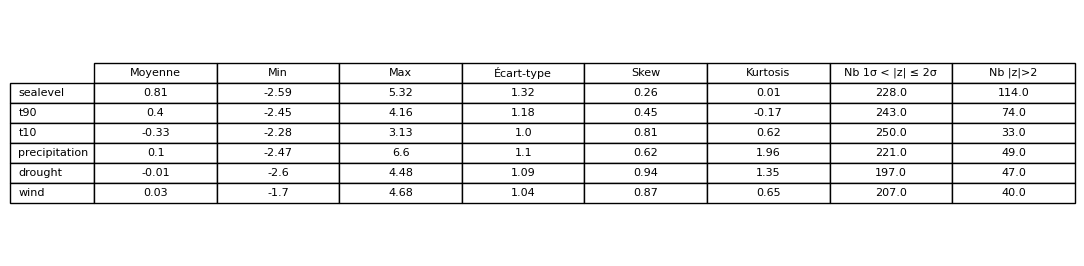

Saved: /Users/coralieroland/Desktop/BACI-climate-index/notebooks/ACI-Python/reports/descriptive_statistics.png


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# New descriptive statistics provided by user
data = {
    "sealevel": {"Moyenne": 0.808, "Min": -2.587, "Max": 5.319, "Écart-type": 1.324,
                 "Skew": 0.256, "Kurtosis": 0.006, "Nb |z|>1": 342, "Nb |z|>2": 114},
    "t90": {"Moyenne": 0.401, "Min": -2.452, "Max": 4.159, "Écart-type": 1.179,
            "Skew": 0.448, "Kurtosis": -0.172, "Nb |z|>1": 317, "Nb |z|>2": 74},
    "t10": {"Moyenne": -0.326, "Min": -2.285, "Max": 3.126, "Écart-type": 1.003,
            "Skew": 0.811, "Kurtosis": 0.621, "Nb |z|>1": 283, "Nb |z|>2": 33},
    "precipitation": {"Moyenne": 0.095, "Min": -2.471, "Max": 6.599, "Écart-type": 1.102,
                      "Skew": 0.622, "Kurtosis": 1.963, "Nb |z|>1": 270, "Nb |z|>2": 49},
    "drought": {"Moyenne": -0.006, "Min": -2.599, "Max": 4.483, "Écart-type": 1.089,
                "Skew": 0.944, "Kurtosis": 1.346, "Nb |z|>1": 244, "Nb |z|>2": 47},
    "wind": {"Moyenne": 0.031, "Min": -1.697, "Max": 4.675, "Écart-type": 1.040,
             "Skew": 0.873, "Kurtosis": 0.649, "Nb |z|>1": 247, "Nb |z|>2": 40},
}

# Build DataFrame
df = pd.DataFrame(data).T

# Moderate band (1σ < |z| ≤ 2σ) = >1σ minus >2σ
df["Nb 1σ < |z| ≤ 2σ"] = df["Nb |z|>1"] - df["Nb |z|>2"]

# Keep only desired columns in order
df_final = df[["Moyenne", "Min", "Max", "Écart-type", "Skew", "Kurtosis",
               "Nb 1σ < |z| ≤ 2σ", "Nb |z|>2"]]

# Optional: fixed row order to match your slides
df_final = df_final.loc[["sealevel", "t90", "t10", "precipitation", "drought", "wind"]]

# ---- Save PNG to your repo (relative path, with auto-mkdir) ----
out_path = Path("ACI-Python/reports/descriptive_statistics.png")
out_path.parent.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.axis('off')
table = ax.table(
    cellText=df_final.round(2).values,
    colLabels=df_final.columns,
    rowLabels=df_final.index,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.15, 1.2)

plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {out_path.resolve()}")


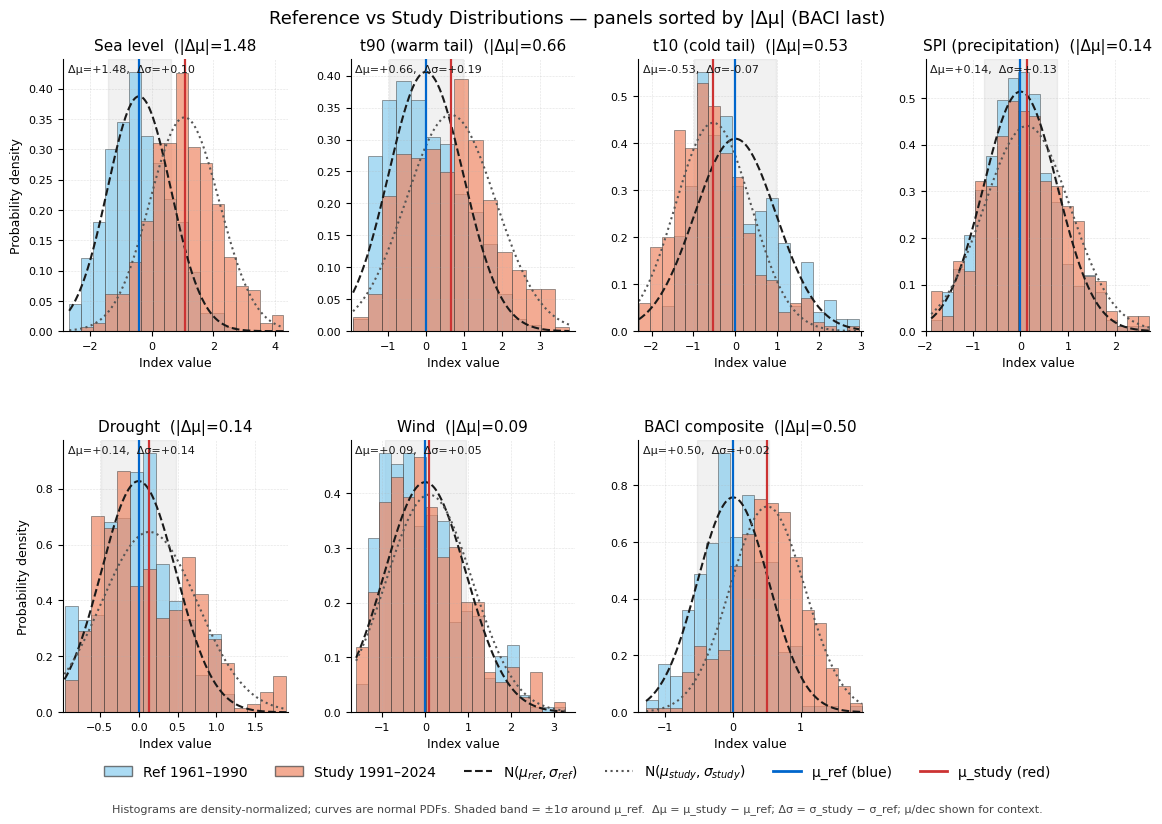

Saved: BACI_all_indices_histograms_A4_delta_only_mu_fixed.png
Saved: BACI_all_indices_histograms_A4_delta_only_mu_fixed.pdf


In [11]:
# A4 one-page multi-index histograms — ONLY Δμ & Δσ per panel
# μ_ref (blue) and μ_study (red) are FIXED, independent of histogram colors.
# ORDER: by |Δμ| (absolute delta-mu) high→low, with BACI composite ALWAYS last.

import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy import stats
from datetime import datetime as _dt
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# ── Periods ────────────────────────────────────────────────────────────────
REF_START, REF_END     = "1961-01-01", "1990-12-31"
STUDY_START, STUDY_END = "1991-01-01", "2024-12-31"

# ── Files ──────────────────────────────────────────────────────────────────
INDEX_PATHS = {
    "SPI (precipitation)": "/Users/coralieroland/ACI-Python/data/composites/precipitation_index.nc",
    "t90 (warm tail)"    : "/Users/coralieroland/ACI-Python/data/composites/t90_index.nc",
    "t10 (cold tail)"    : "/Users/coralieroland/ACI-Python/data/composites/t10_index.nc",
    "Drought"            : "/Users/coralieroland/ACI-Python/data/composites/drought_index.nc",
    "Wind"               : "/Users/coralieroland/ACI-Python/data/composites/wind_index.nc",
    "Sea level"          : "/Users/coralieroland/ACI-Python/data/composites/sealevel_index.nc",
    "BACI composite"     : "/Users/coralieroland/ACI-Python/data/composites/BACI_composite.nc",
}

# ── Output ─────────────────────────────────────────────────────────────────
FIGSIZE_A4 = (11.69, 8.27)  # landscape
OUT_PNG = "BACI_all_indices_histograms_A4_delta_only_mu_fixed.png"
OUT_PDF = "BACI_all_indices_histograms_A4_delta_only_mu_fixed.pdf"

# ── Options ────────────────────────────────────────────────────────────────
SHARE_Y = False  # set True for identical y scale across panels

# ── Colors (palette for fills; FIXED colors for mean lines) ────────────────
H_REF   = "#88CCEE"   # Tol light blue
H_STUDY = "#EE8866"   # Tol coral/orange
MU_REF_COLOR   = "#0066CC"  # BLUE
MU_STUDY_COLOR = "#CC3333"  # RED
CURVE_REF   = "#1A1A1A"     # dashed normal (ref)
CURVE_STUDY = "#555555"     # dotted normal (study)
EDGE        = "#404040"
SHADE       = (0.10, 0.10, 0.10, 0.06)  # ±1σ_ref band (neutral)

plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 11, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
})

# ── Helpers ────────────────────────────────────────────────────────────────
def load_monthly_series(path: str):
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    try:
        da = xr.open_dataarray(path, chunks="auto")
    except Exception:
        ds = xr.open_dataset(path, chunks="auto")
        da = next((ds[v] for v in ds.data_vars if "time" in ds[v].dims and ds[v].ndim == 1), None)
        if da is None:
            raise ValueError(f"No 1D time series in {path}")
    da = da.sortby("time")
    if "step" in da.dims:
        da = da.mean("step", skipna=True, keep_attrs=True)
    if xr.infer_freq(da.time) not in ("ME", "MS"):
        da = da.resample(time="ME").mean()
    da = da.sel(time=slice(REF_START, STUDY_END)).astype("float32")
    return da.to_series().dropna()

def fd_bins(values: np.ndarray, max_bins: int = 50):
    edges = np.histogram_bin_edges(values, bins="fd")
    if len(edges) < 5:
        edges = np.linspace(np.nanmin(values), np.nanmax(values), 31)
    if len(edges) > max_bins:
        edges = np.linspace(edges[0], edges[-1], max_bins)
    return edges

def robust_xlim(v: np.ndarray, q=0.995):
    v = v[np.isfinite(v)]
    if v.size == 0: return (-1, 1)
    lo, hi = np.quantile(v, [1 - q, q])
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        lo, hi = v.min(), v.max()
    pad = 0.04 * (hi - lo if hi > lo else 1.0)
    return (lo - pad, hi + pad)

def mean_sd(v):
    v = np.asarray(v); v = v[np.isfinite(v)]
    n = len(v)
    mu = float(np.mean(v)) if n else np.nan
    sd = float(np.std(v, ddof=1)) if n > 1 else np.nan
    return mu, (sd if (sd and sd > 0) else np.nan)

def _period_mid(dt_start: str, dt_end: str):
    a, b = _dt.fromisoformat(dt_start), _dt.fromisoformat(dt_end)
    return a + (b - a) / 2

def _is_baci(name: str) -> bool:
    n = name.lower()
    return "baci" in n and "composite" in n

# Δt in decades between period midpoints (still used for μ/dec shown in title)
REF_MID   = _period_mid(REF_START, REF_END)
STUDY_MID = _period_mid(STUDY_START, STUDY_END)
DECADES_GAP = max(((STUDY_MID - REF_MID).days) / (365.2425 * 10.0), 1e-9)

# ── Load series ────────────────────────────────────────────────────────────
series = {}      # name -> (s_all, s_ref, s_study)
for name, path in INDEX_PATHS.items():
    try:
        s = load_monthly_series(path)
        s_ref   = s.loc[REF_START:REF_END]
        s_study = s.loc[STUDY_START:STUDY_END]
        if s_ref.empty or s_study.empty:
            print(f"[SKIP] {name}: empty ref or study.")
            continue
        series[name] = (s, s_ref, s_study)
    except Exception as e:
        print(f"[SKIP] {name}: {e}")

if not series:
    raise RuntimeError("No indices available to plot.")

# ── Precompute per-index meta (Δμ, μ/dec, edges, limits, etc.) ────────────
meta = {}
global_ymax = 0.0
for name, (s_all, s_ref, s_study) in series.items():
    xlo, xhi = robust_xlim(s_all.values, q=0.995)
    trimmed = s_all.values[(s_all.values >= xlo) & (s_all.values <= xhi)]
    edges = fd_bins(trimmed, max_bins=50)
    x = np.linspace(edges[0], edges[-1], 800)

    mu_r, sd_r = mean_sd(s_ref.values)
    mu_s, sd_s = mean_sd(s_study.values)
    delta_mu = mu_s - mu_r
    mu_dec = delta_mu / DECADES_GAP

    sd_r = 1.0 if (not np.isfinite(sd_r) or sd_r == 0) else sd_r
    sd_s = 1.0 if (not np.isfinite(sd_s) or sd_s == 0) else sd_s

    c1, _ = np.histogram(s_ref.values,   bins=edges, density=True)
    c2, _ = np.histogram(s_study.values, bins=edges, density=True)
    ymax = max(c1.max() if c1.size else 0, c2.max() if c2.size else 0,
               stats.norm.pdf(mu_r, mu_r, sd_r))
    global_ymax = max(global_ymax, ymax)

    meta[name] = dict(
        xlo=xlo, xhi=xhi, edges=edges, x=x,
        mu_r=mu_r, sd_r=sd_r, mu_s=mu_s, sd_s=sd_s,
        delta_mu=delta_mu, mu_dec=mu_dec
    )

if SHARE_Y:
    global_ymax *= 1.12

# ── Order by |Δμ| (desc), with BACI last ──────────────────────────────────
names_all = list(series.keys())
others = [n for n in names_all if not _is_baci(n)]
baci   = [n for n in names_all if _is_baci(n)]

def _order_key(n):
    v = meta[n]["delta_mu"]
    if not np.isfinite(v):  # NaNs last among 'others'
        return (1, 0.0)
    return (0, -abs(v))     # largest |Δμ| first

others_sorted = sorted(others, key=_order_key)
names = others_sorted + baci  # BACI (if present) at the very end

# ── Grid size ──────────────────────────────────────────────────────────────
n = len(names)
ncols = 3 if n <= 6 else 4
nrows = int(np.ceil(n / ncols))

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(nrows, ncols, figsize=FIGSIZE_A4)
axes = np.atleast_2d(axes).ravel()

for i, name in enumerate(names):
    ax = axes[i]
    s_all, s_ref, s_study = series[name]
    m = meta[name]
    edges, x = m["edges"], m["x"]
    mu_r, sd_r, mu_s, sd_s = m["mu_r"], m["sd_r"], m["mu_s"], m["sd_s"]

    # Density histograms
    ax.hist(s_ref.values,   bins=edges, density=True, color=H_REF,   alpha=0.70,
            edgecolor=EDGE, linewidth=0.5, label="_nolegend_")
    ax.hist(s_study.values, bins=edges, density=True, color=H_STUDY, alpha=0.70,
            edgecolor=EDGE, linewidth=0.5, label="_nolegend_")

    # ±1σ_ref band
    ax.fill_between([mu_r - sd_r, mu_r + sd_r], 0, 1,
                    transform=ax.get_xaxis_transform(), color=SHADE, zorder=0)

    # Normal overlays
    ax.plot(x, stats.norm.pdf(x, mu_r, sd_r), ls="--", lw=1.5, color=CURVE_REF)
    ax.plot(x, stats.norm.pdf(x, mu_s, sd_s), ls=":",  lw=1.5, color=CURVE_STUDY)

    # Mean lines — FIXED colors
    ax.axvline(mu_r, color=MU_REF_COLOR,   lw=1.6)
    ax.axvline(mu_s, color=MU_STUDY_COLOR, lw=1.6)

    # ONLY Δμ / Δσ label (top-left)
    ax.text(0.02, 0.98, f"Δμ={mu_s - mu_r:+.2f},  Δσ={sd_s - sd_r:+.2f}",
            transform=ax.transAxes, va="top", ha="left", fontsize=8, color="#1a1a1a")

    # Title — show |Δμ| and μ/dec for context
    ax.set_title(f"{name}  (|Δμ|={abs(m['delta_mu']):.2f}")

    # Cosmetics
    ax.set_xlim(m["xlo"], m["xhi"])
    if SHARE_Y: ax.set_ylim(0, global_ymax)
    ax.set_xlabel("Index value")
    if i % ncols == 0:
        ax.set_ylabel("Probability density")
    ax.grid(True, ls=":", lw=0.4, alpha=0.7)

# Remove unused axes
total_axes = nrows * ncols
for j in range(len(names), total_axes):
    fig.delaxes(axes[j])

# ── Shared legend — hist fills + normals + μ lines (blue/red fixed) ───────
handles = [
    Patch(facecolor=H_REF,   edgecolor=EDGE, alpha=0.70, label="Ref 1961–1990"),
    Patch(facecolor=H_STUDY, edgecolor=EDGE, alpha=0.70, label="Study 1991–2024"),
    Line2D([0], [0], ls="--", color=CURVE_REF,   lw=1.5, label="N($\\mu_{ref},\\sigma_{ref}$)"),
    Line2D([0], [0], ls=":",  color=CURVE_STUDY, lw=1.5, label="N($\\mu_{study},\\sigma_{study}$)"),
    Line2D([0], [0], color=MU_REF_COLOR,   lw=2.0, label="μ_ref (blue)"),
    Line2D([0], [0], color=MU_STUDY_COLOR, lw=2.0, label="μ_study (red)"),
]
fig.legend(handles=handles, ncol=6, frameon=False, loc="lower center", bbox_to_anchor=(0.5, 0.03))

# Title, footnote, layout ---------------------------------------------------
fig.suptitle("Reference vs Study Distributions — panels sorted by |Δμ| (BACI last)",
             y=0.98, fontsize=13)
plt.subplots_adjust(left=0.06, right=0.99, top=0.92, bottom=0.13, wspace=0.28, hspace=0.40)
fig.text(0.5, 0.007,
         "Histograms are density-normalized; curves are normal PDFs. Shaded band = ±1σ around μ_ref."
         "  Δμ = μ_study − μ_ref; Δσ = σ_study − σ_ref; μ/dec shown for context.",
         ha="center", va="bottom", fontsize=8, color="#444")

fig.savefig(OUT_PNG, dpi=300)
fig.savefig(OUT_PDF, dpi=300)
plt.show()
print(f"Saved: {OUT_PNG}\nSaved: {OUT_PDF}")


SPI (precipitation) — months:  768  |  ≤1σ:  598 (77.9%)   1–2σ:  158 (20.6%)   >2σ:   12 ( 1.6%)   P(|x|>1σ)= 22.1%
t90 (warm tail)  — months:  634  |  ≤1σ:  369 (58.2%)   1–2σ:  213 (33.6%)   >2σ:   52 ( 8.2%)   P(|x|>1σ)= 41.8%
t10 (cold tail)  — months:  634  |  ≤1σ:  413 (65.1%)   1–2σ:  196 (30.9%)   >2σ:   25 ( 3.9%)   P(|x|>1σ)= 34.9%
Drought          — months:  768  |  ≤1σ:  723 (94.1%)   1–2σ:   45 ( 5.9%)   >2σ:    0 ( 0.0%)   P(|x|>1σ)=  5.9%
Wind             — months:  768  |  ≤1σ:  551 (71.7%)   1–2σ:  182 (23.7%)   >2σ:   35 ( 4.6%)   P(|x|>1σ)= 28.3%
Sea level        — months:  730  |  ≤1σ:  380 (52.1%)   1–2σ:  251 (34.4%)   >2σ:   99 (13.6%)   P(|x|>1σ)= 47.9%
BACI composite   — months:  634  |  ≤1σ:  552 (87.1%)   1–2σ:   82 (12.9%)   >2σ:    0 ( 0.0%)   P(|x|>1σ)= 12.9%


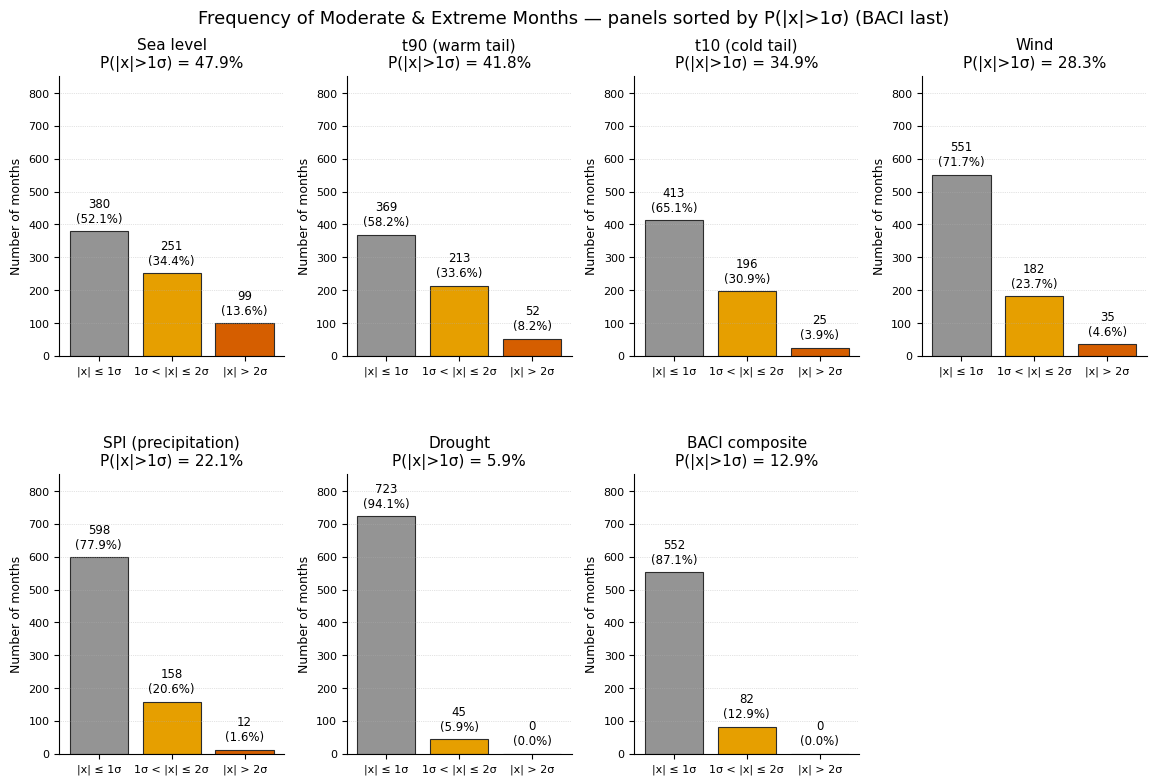

Saved: BACI_all_indices_frequency_3bars_A4_sorted_gt1sigma.png
Saved: BACI_all_indices_frequency_3bars_A4_sorted_gt1sigma.pdf


In [12]:
# One-page A4 — 3-bar frequency charts for EVERY index (|x|≤1, 1<|x|≤2, |x|>2)
# - Robust monthly loading (handles `step`, resampling to ME)
# - Counts per index, with % annotations
# - Panels ordered by share of months with |x| > 1σ (high → low), with BACI composite ALWAYS last
# - Global y-limit for comparability across panels
# - Skips any missing files gracefully

import os
import warnings
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=RuntimeWarning)

# ── Config ─────────────────────────────────────────────────────────────────
START_DATE = "1961-01-01"
END_DATE   = None  # None → to the end of each series
OUT_PNG    = "BACI_all_indices_frequency_3bars_A4_sorted_gt1sigma.png"
OUT_PDF    = "BACI_all_indices_frequency_3bars_A4_sorted_gt1sigma.pdf"

# Indices (edit paths if needed)
INDEX_PATHS = {
    "SPI (precipitation)": "/Users/coralieroland/ACI-Python/data/composites/precipitation_index.nc",
    "t90 (warm tail)"    : "/Users/coralieroland/ACI-Python/data/composites/t90_index.nc",
    "t10 (cold tail)"    : "/Users/coralieroland/ACI-Python/data/composites/t10_index.nc",
    "Drought"            : "/Users/coralieroland/ACI-Python/data/composites/drought_index.nc",
    "Wind"               : "/Users/coralieroland/ACI-Python/data/composites/wind_index.nc",
    "Sea level"          : "/Users/coralieroland/ACI-Python/data/composites/sealevel_index.nc",
    "BACI composite"     : "/Users/coralieroland/ACI-Python/data/composites/BACI_composite.nc",
}

# Okabe–Ito colors (color-blind safe)
C_LE1  = "#949494"  # |x| ≤ 1
C_1TO2 = "#E69F00"  # 1 < |x| ≤ 2
C_GT2  = "#D55E00"  # |x| > 2
C_EDGE = "#2C2C2C"

# Layout
FIGSIZE_A4 = (11.69, 8.27)  # landscape A4 in inches
N_COLS_DEFAULT = 4  # 7 indices → 2 rows × 4 cols looks good

# ── Helpers ────────────────────────────────────────────────────────────────
def open_monthly_series(path: str):
    """Return a monthly-end pandas Series trimmed to [START_DATE, END_DATE]."""
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    try:
        da = xr.open_dataarray(path, chunks="auto")
    except Exception:
        ds = xr.open_dataset(path, chunks="auto")
        da = next((ds[v] for v in ds.data_vars if "time" in ds[v].dims and ds[v].ndim == 1), None)
        if da is None:
            raise ValueError(f"No 1D time series in {path}")

    da = da.sortby("time")
    if "step" in da.dims:
        da = da.mean("step", skipna=True, keep_attrs=True)

    freq = xr.infer_freq(da.time)
    if freq not in ("ME", "MS"):
        da = da.resample(time="ME").mean()
    elif freq == "MS":
        da = da.resample(time="ME").mean()

    da = da.sel(time=slice(START_DATE, END_DATE)).astype("float32").compute()
    s = da.to_series()
    s = s[np.isfinite(s.values)]
    return s

def three_bin_counts(values: np.ndarray):
    abs_v = np.abs(values)
    n_tot = abs_v.size
    le1   = int(np.count_nonzero(abs_v <= 1.0))
    b12   = int(np.count_nonzero((abs_v > 1.0) & (abs_v <= 2.0)))
    gt2   = int(np.count_nonzero(abs_v > 2.0))
    counts = np.array([le1, b12, gt2], dtype=int)
    denom  = max(n_tot, 1)
    perc   = counts / denom * 100.0
    return n_tot, counts, perc

def _is_baci(name: str) -> bool:
    n = name.lower()
    return "baci" in n and "composite" in n

# ── Load all indices & compute counts + share(|x|>1σ) ─────────────────────
results = []  # (name, n_tot, counts[3], percents[3], p_gt1)
for name, path in INDEX_PATHS.items():
    try:
        s = open_monthly_series(path)
        n_tot, counts, perc = three_bin_counts(s.to_numpy())
        p_gt1 = float(perc[1] + perc[2])  # percent of months with |x| > 1σ
        print(f"{name:16s} — months: {n_tot:4d}  |  ≤1σ: {counts[0]:4d} ({perc[0]:4.1f}%)"
              f"   1–2σ: {counts[1]:4d} ({perc[1]:4.1f}%)   >2σ: {counts[2]:4d} ({perc[2]:4.1f}%)"
              f"   P(|x|>1σ)={p_gt1:5.1f}%")
        results.append((name, n_tot, counts, perc, p_gt1))
    except Exception as e:
        print(f"[SKIP] {name}: {e}")

if not results:
    raise RuntimeError("No indices available. Check paths and data.")

# ── Order panels by P(|x|>1σ) (desc), with BACI last ──────────────────────
others = [r for r in results if not _is_baci(r[0])]
baci   = [r for r in results if _is_baci(r[0])]

# sort: finite first, then by descending P(|x|>1σ)
others_sorted = sorted(
    others,
    key=lambda r: (not np.isfinite(r[4]), -r[4])
)
ordered = others_sorted + baci  # append BACI (if present) at the end

# ── Figure grid & global y-limit ──────────────────────────────────────────
max_count = max(r[2].max() for r in ordered)  # largest bin across indices

n = len(ordered)
ncols = N_COLS_DEFAULT if n > 6 else 3
nrows = int(np.ceil(n / ncols))

plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 11, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
})

fig, axes = plt.subplots(nrows, ncols, figsize=FIGSIZE_A4)
axes = np.atleast_2d(axes).ravel()

labels = ["|x| ≤ 1σ", "1σ < |x| ≤ 2σ", "|x| > 2σ"]
bar_colors = [C_LE1, C_1TO2, C_GT2]

for i, (name, n_tot, counts, perc, p_gt1) in enumerate(ordered):
    ax = axes[i]
    bars = ax.bar(labels, counts, color=bar_colors, edgecolor=C_EDGE, linewidth=0.8)

    ax.set_title(f"{name}\nP(|x|>1σ) = {p_gt1:.1f}%")
    ax.set_ylabel("Number of months")
    ax.grid(True, axis="y", ls=":", lw=0.5, alpha=0.7)
    ymax = max_count if max_count > 0 else 1
    ax.set_ylim(0, ymax * 1.18)

    # annotate bars with count + %
    for bar, pct in zip(bars, perc):
        y = int(bar.get_height())
        ax.text(
            bar.get_x() + bar.get_width()/2, y + ymax * 0.025,
            f"{y:,}\n({pct:.1f}%)",
            ha="center", va="bottom", fontsize=8.5
        )

# remove unused axes, if any
total_axes = nrows * ncols
for j in range(len(ordered), total_axes):
    fig.delaxes(axes[j])

# overall title & layout
fig.suptitle("Frequency of Moderate & Extreme Months — panels sorted by P(|x|>1σ) (BACI last)",
             y=0.98, fontsize=13)
plt.subplots_adjust(left=0.06, right=0.99, top=0.90, bottom=0.08, wspace=0.28, hspace=0.42)

fig.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
fig.savefig(OUT_PDF, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_PNG}\nSaved: {OUT_PDF}")


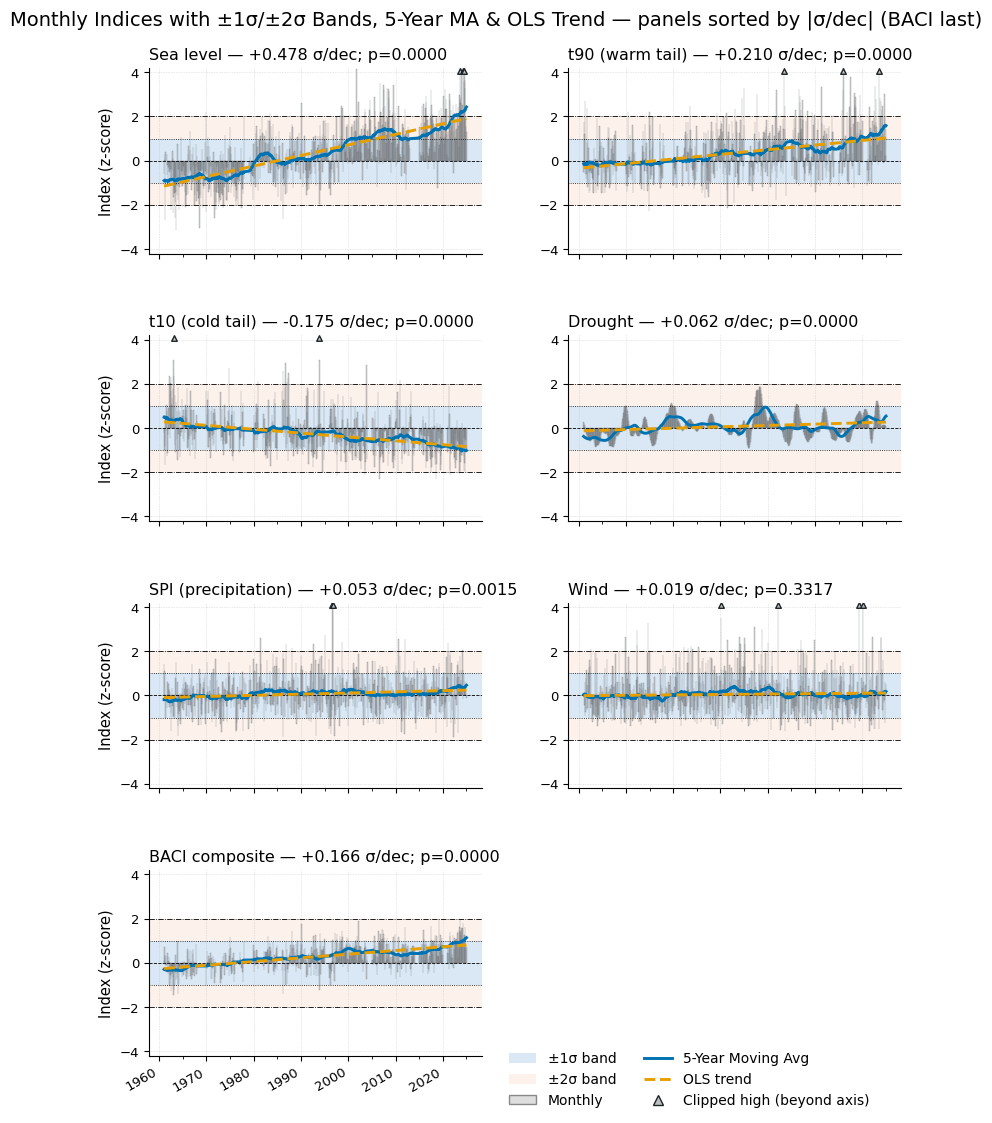

Sea level        | slope=0.04779 σ/yr (0.478 σ/dec) CI95=[0.04394,0.05164]  p=1.66e-96  n=730  clipped_hi=3 clipped_lo=0  ylim=±4.2
t90 (warm tail)  | slope=0.02098 σ/yr (0.210 σ/dec) CI95=[0.01645,0.02550]  p=1.157e-18  n=634  clipped_hi=3 clipped_lo=0  ylim=±4.2
t10 (cold tail)  | slope=-0.01748 σ/yr (-0.175 σ/dec) CI95=[-0.02131,-0.01365]  p=3.687e-18  n=634  clipped_hi=2 clipped_lo=0  ylim=±4.2
Drought          | slope=0.00615 σ/yr (0.062 σ/dec) CI95=[0.00404,0.00827]  p=1.592e-08  n=768  clipped_hi=0 clipped_lo=0  ylim=±4.2
SPI (precipitation) | slope=0.00526 σ/yr (0.053 σ/dec) CI95=[0.00202,0.00850]  p=0.001494  n=768  clipped_hi=2 clipped_lo=0  ylim=±4.2
Wind             | slope=0.00186 σ/yr (0.019 σ/dec) CI95=[-0.00190,0.00561]  p=0.3317  n=768  clipped_hi=4 clipped_lo=0  ylim=±4.2
BACI composite   | slope=0.01664 σ/yr (0.166 σ/dec) CI95=[0.01450,0.01878]  p=4.114e-45  n=634  clipped_hi=0 clipped_lo=0  ylim=±4.2
Saved: BACI_timeseries_OptionA_2x4_portrait.png
Saved: BACI_timese

In [14]:
# BACI — Multi-index timeseries (Option A), 2 columns × 4 rows, bigger panels
# ORDER: by |σ/dec| (absolute slope per decade) high→low, with BACI composite ALWAYS last.
# Legend explains triangles; σ-bands slightly darker for contrast.

import os
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy import stats
from scipy.stats import t as tdist

warnings.filterwarnings("ignore", category=RuntimeWarning)

# ── Config ─────────────────────────────────────────────────────────────────
START_DATE = "1961-01-01"
END_DATE   = None  # None → to series end

OUT_PNG = "BACI_timeseries_OptionA_2x4_portrait.png"
OUT_PDF = "BACI_timeseries_OptionA_2x4_portrait.pdf"

INDEX_PATHS = {
    "SPI (precipitation)": "/Users/coralieroland/ACI-Python/data/composites/precipitation_index.nc",
    "t90 (warm tail)"    : "/Users/coralieroland/ACI-Python/data/composites//t90_index.nc",
    "t10 (cold tail)"    : "/Users/coralieroland/ACI-Python/data/composites//t10_index.nc",
    "Drought"            : "/Users/coralieroland/ACI-Python/data/composites//drought_index.nc",
    "Wind"               : "/Users/coralieroland/ACI-Python/data/composites//wind_index.nc",
    "Sea level"          : "/Users/coralieroland/ACI-Python/data/composites/sealevel_index.nc",
    "BACI composite"     : "/Users/coralieroland/ACI-Python/data/composites/BACI_composite.nc",
}

# Layout: portrait A4, 2 columns × up to 4 rows
FIGSIZE_A4_PORTRAIT = (8.27, 11.69)   # inches
N_MAJOR_YEARS = 10                    # major ticks every 10 years
N_MINOR_YEARS = 5                     # minor ticks every 5 years
NCOLS = 2
GLOBAL_Y = True                       # same ±ylim across panels

# Style (Okabe–Ito-ish) with darker bands for contrast
C = {
    "bars":  "#BFBFBF",      # monthly bars
    "roll":  "#0072B2",      # 5-year MA (blue)
    "trend": "#E69F00",      # OLS trend (orange)
    "edge":  "#1F2428",
    "band1": "#9FC4E7",      # darker than #C7DFF1
    "band2": "#F3B99D",      # darker than #F8D9C7
}
BAND1_ALPHA = 0.38
BAND2_ALPHA = 0.20
BAR_ALPHA   = 0.50
BAR_WIDTH   = 28
CLIP_MARKER_SIZE = 16

plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 11.5, "axes.labelsize": 10.5,
    "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
})

# ── Helpers ────────────────────────────────────────────────────────────────
def open_monthly_series(path: str, start=START_DATE, end=END_DATE) -> pd.Series:
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    try:
        da = xr.open_dataarray(path, chunks="auto")
    except Exception:
        ds = xr.open_dataset(path, chunks="auto")
        da = next((ds[v] for v in ds.data_vars if "time" in ds[v].dims and ds[v].ndim == 1), None)
        if da is None:
            raise ValueError(f"No 1D time series in {path}")

    da = da.sortby("time")
    if "step" in da.dims:
        da = da.mean("step", skipna=True, keep_attrs=True)

    freq = xr.infer_freq(da.time)
    if freq not in ("ME", "MS"):
        da = da.resample(time="ME").mean()
    elif freq == "MS":
        da = da.resample(time="ME").mean()

    da = da.sel(time=slice(start, end)).astype("float32").compute()
    s = da.to_series().dropna()
    s.index = pd.to_datetime(s.index).to_period("M").to_timestamp("M")
    return s

def panel_stats(series: pd.Series):
    roll = series.rolling(60, center=True, min_periods=30).mean()  # 5-year
    years = series.index.year + (series.index.dayofyear - 1) / 365.2425
    y = series.values.astype(float)
    slope, intercept, r, p, stderr = stats.linregress(years, y)
    trend = pd.Series(intercept + slope * years, index=series.index)
    n = len(y); df = n - 2
    tcrit = tdist.ppf(0.975, df) if df > 0 else np.nan
    slope_ci = (slope - tcrit * stderr, slope + tcrit * stderr) if np.isfinite(tcrit) else (np.nan, np.nan)
    q = float(np.nanquantile(np.abs(y), 0.995)) if y.size else 3.0
    ylim = max(3.0, np.ceil(q * 10) / 10.0)
    hi = series[series >  ylim]
    lo = series[series < -ylim]
    return roll, trend, slope, p, slope_ci, ylim, hi, lo

def is_baci(name: str) -> bool:
    n = name.lower()
    return "baci" in n and "composite" in n

# ── Load series ────────────────────────────────────────────────────────────
items = []  # tuples: (name, s, roll, trend, slope, p, ci, ylim, hi, lo)
for name, path in INDEX_PATHS.items():
    try:
        s = open_monthly_series(path)
        roll, trend, slope, p, ci, ylim, hi, lo = panel_stats(s)
        items.append((name, s, roll, trend, slope, p, ci, ylim, hi, lo))
    except Exception as e:
        print(f"[SKIP] {name}: {e}")

if not items:
    raise RuntimeError("No indices available. Check paths and data.")

# Global symmetric ylim if requested
if GLOBAL_Y:
    global_q = max(float(np.nanquantile(np.abs(s.values), 0.995)) for _, s, *_ in items)
    GLOBAL_YLIM = max(3.0, np.ceil(global_q * 10) / 10.0)
else:
    GLOBAL_YLIM = None

# ── ORDER by |slope/dec| (desc), ensuring BACI at the end ─────────────────
others = [t for t in items if not is_baci(t[0])]
baci   = [t for t in items if is_baci(t[0])]

def _abs_sdec_key(t):
    sdec = t[4] * 10.0  # slope per decade
    finite = 0 if np.isfinite(sdec) else 1       # finite first
    magneg = -abs(sdec) if np.isfinite(sdec) else 0.0  # larger |sdec| first
    return (finite, magneg)

others_sorted = sorted(others, key=_abs_sdec_key)
ordered = others_sorted + baci  # BACI (if present) at the very end

# ── Layout: 2 columns × rows (≤ 4) ────────────────────────────────────────
n = len(ordered)
ncols = NCOLS
nrows = int(np.ceil(n / ncols))
nrows = min(nrows, 4)

fig, axes = plt.subplots(nrows, ncols, figsize=FIGSIZE_A4_PORTRAIT, sharex=True)
axes = np.atleast_2d(axes).ravel()

# Number of panels we can draw
K = min(nrows * ncols, n)

# If BACI exists and we have to drop panels to fit K, keep top K-1 others + BACI
if baci and len(ordered) > K:
    draw_items = others_sorted[:max(0, K - 1)] + baci[:1]
else:
    draw_items = ordered[:K]

# ── Draw panels ────────────────────────────────────────────────────────────
for i, (name, s, roll, trend, slope, p, ci, ylim, hi, lo) in enumerate(draw_items):
    ax = axes[i]
    y_lim = GLOBAL_YLIM if GLOBAL_YLIM is not None else ylim

    # σ-bands (slightly darker)
    ax.axhspan(-1,  1, facecolor=C["band1"], alpha=BAND1_ALPHA, zorder=0)
    ax.axhspan( 1,  2, facecolor=C["band2"], alpha=BAND2_ALPHA, zorder=0)
    ax.axhspan(-2, -1, facecolor=C["band2"], alpha=BAND2_ALPHA, zorder=0)

    # monthly bars
    ax.bar(s.index, s.values, width=BAR_WIDTH, color=C["bars"], edgecolor=C["edge"],
           linewidth=0.25, alpha=BAR_ALPHA, align="center", zorder=1)

    # clipped markers (kept inside frame)
    if len(hi):
        ax.scatter(hi.index, np.full(len(hi),  y_lim - 0.03*y_lim), marker="^", s=CLIP_MARKER_SIZE,
                   facecolor=C["bars"], edgecolor=C["edge"], zorder=4)
    if len(lo):
        ax.scatter(lo.index, np.full(len(lo), -y_lim + 0.03*y_lim), marker="v", s=CLIP_MARKER_SIZE,
                   facecolor=C["bars"], edgecolor=C["edge"], zorder=4)

    # lines
    ax.plot(roll.index,  roll.values,  color=C["roll"],  lw=2.1, label="5-Year Moving Avg", zorder=3)
    ax.plot(trend.index, trend.values, color=C["trend"], ls="--", lw=2.1, label="OLS trend", zorder=3)

    # reference lines
    for yref, ls in [(0, "--"), (1, ":"), (-1, ":"), (2, "-."), (-2, "-.")]:
        ax.axhline(yref, color="black", lw=0.6, ls=ls, zorder=2)

    ax.set_ylim(-y_lim, y_lim)
    ax.grid(True, ls=":", lw=0.45, alpha=0.65)
    ax.set_title(f"{name} — {slope*10:+.3f} σ/dec; p={p:.4f}", loc="left")

    if i % ncols == 0:
        ax.set_ylabel("Index (z-score)")

# remove unused axes
for j in range(i + 1, nrows * ncols):
    fig.delaxes(axes[j])

# ── Time axis formatting ──────────────────────────────────────────────────
for idx, ax in enumerate(axes[:len(draw_items)]):
    ax.xaxis.set_major_locator(mdates.YearLocator(base=N_MAJOR_YEARS))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.YearLocator(base=N_MINOR_YEARS))
for idx, ax in enumerate(axes[:len(draw_items)]):
    if idx // ncols < nrows - 1:
        ax.tick_params(labelbottom=False)
fig.autofmt_xdate()

# ── Shared legend (now includes triangles explanation) ────────────────────
band1_leg = Patch(facecolor=C["band1"], alpha=BAND1_ALPHA, edgecolor="none", label="±1σ band")
band2_leg = Patch(facecolor=C["band2"], alpha=BAND2_ALPHA, edgecolor="none", label="±2σ band")
bars_proxy = Patch(facecolor=C["bars"], edgecolor=C["edge"], alpha=BAR_ALPHA, label="Monthly")
line_roll  = Line2D([0], [0], color=C["roll"],  lw=2.1, label="5-Year Moving Avg")
line_trend = Line2D([0], [0], color=C["trend"], lw=2.1, ls="--", label="OLS trend")
tri_hi = Line2D([0], [0], marker="^", linestyle="None", markersize=7,
                markerfacecolor=C["bars"], markeredgecolor=C["edge"],
                label="Clipped high (beyond axis)")

legend_handles = [band1_leg, band2_leg, bars_proxy, line_roll, line_trend, tri_hi]
legend_labels  = [h.get_label() for h in legend_handles]
fig.legend(legend_handles, legend_labels, ncol=2, frameon=False,
           loc="lower left", bbox_to_anchor=(0.5, 0.045))

# ── Title, spacing, export ────────────────────────────────────────────────
fig.suptitle("Monthly Indices with ±1σ/±2σ Bands, 5-Year MA & OLS Trend — panels sorted by |σ/dec| (BACI last)",
             y=0.995, fontsize=14)
plt.subplots_adjust(left=0.08, right=0.99, top=0.945, bottom=0.10, wspace=0.26, hspace=0.44)

fig.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
fig.savefig(OUT_PDF, dpi=300, bbox_inches="tight")
plt.show()

# Console summary (printed in the same draw order)
for name, s, roll, trend, slope, p, ci, ylim, hi, lo in draw_items:
    print(
        f"{name:16s} | slope={slope:.5f} σ/yr ({slope*10:.3f} σ/dec) "
        f"CI95=[{ci[0]:.5f},{ci[1]:.5f}]  p={p:.4g}  n={len(s)}  "
        f"clipped_hi={len(hi)} clipped_lo={len(lo)}  "
        f"ylim=±{(GLOBAL_YLIM if GLOBAL_Y else ylim):g}"
    )

print(f"Saved: {OUT_PNG}\nSaved: {OUT_PDF}")



📏 Reference-period (1961–1990) sanity check (mean≈0, std≈1):
      precipitation    t90    t10  drought   wind  sealevel
mean         -0.000 -0.000 -0.000   -0.000  0.000    -0.000
std           1.001  1.001  1.001    1.001  1.001     1.001

BACI composite calculated successfully! 📊 Stats summary:
min:  -1.462
max:  2.203
mean: 0.274
std:  0.584

🔗 Correlation matrix between composites:
               precipitation    t90    t10  drought   wind  sealevel   BACI
precipitation          1.000 -0.048 -0.051   -0.387  0.377     0.345  0.433
t90                   -0.048  1.000 -0.730    0.139  0.007     0.327  0.698
t10                   -0.051 -0.730  1.000    0.030 -0.061    -0.403 -0.707
drought               -0.387  0.139  0.030    1.000 -0.277    -0.270  0.044
wind                   0.377  0.007 -0.061   -0.277  1.000     0.345  0.478
sealevel               0.345  0.327 -0.403   -0.270  0.345     1.000  0.726
BACI                   0.433  0.698 -0.707    0.044  0.478     0.726  1.000



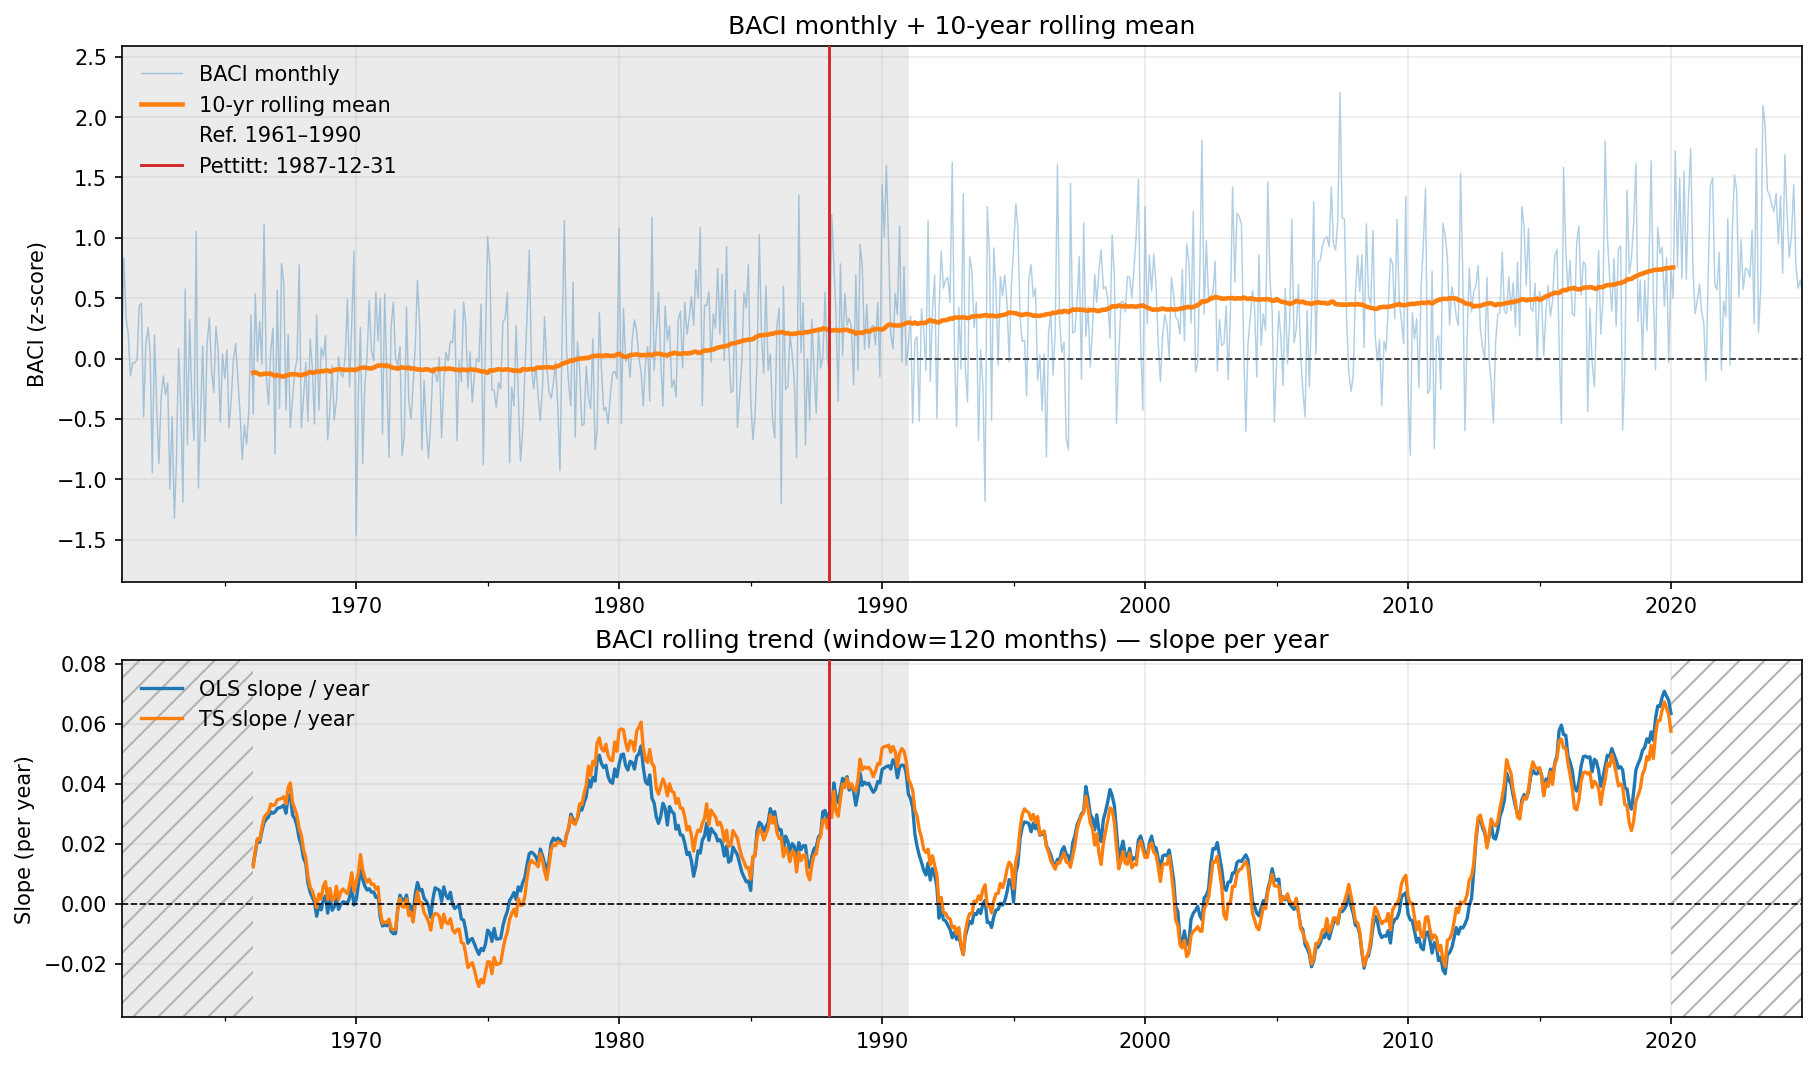

🖼️ Saved combined figure → ACI-Python/data/composites/BACI_levels_and_trends_combined.png


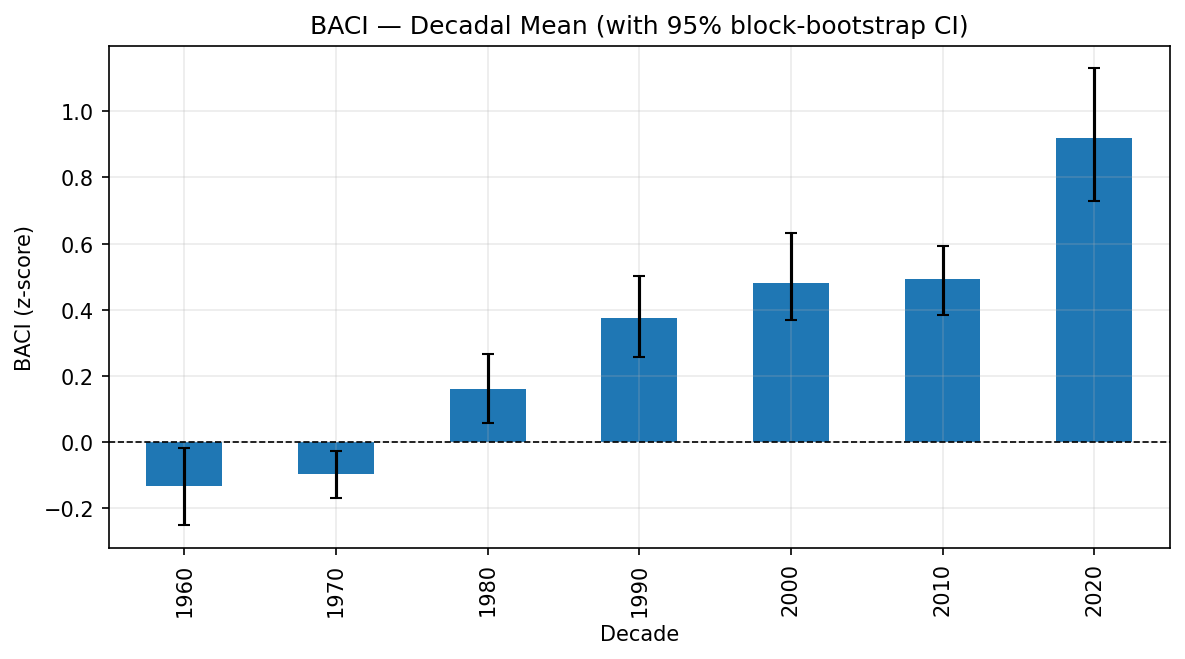

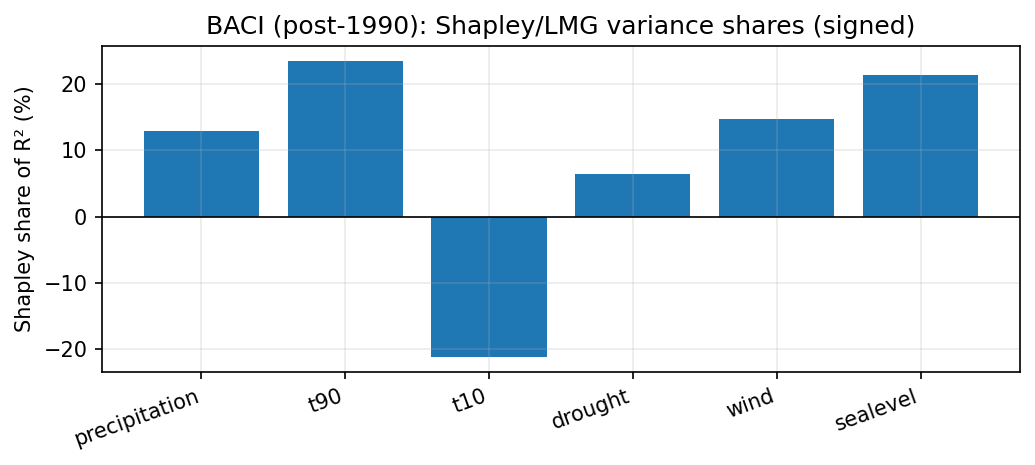

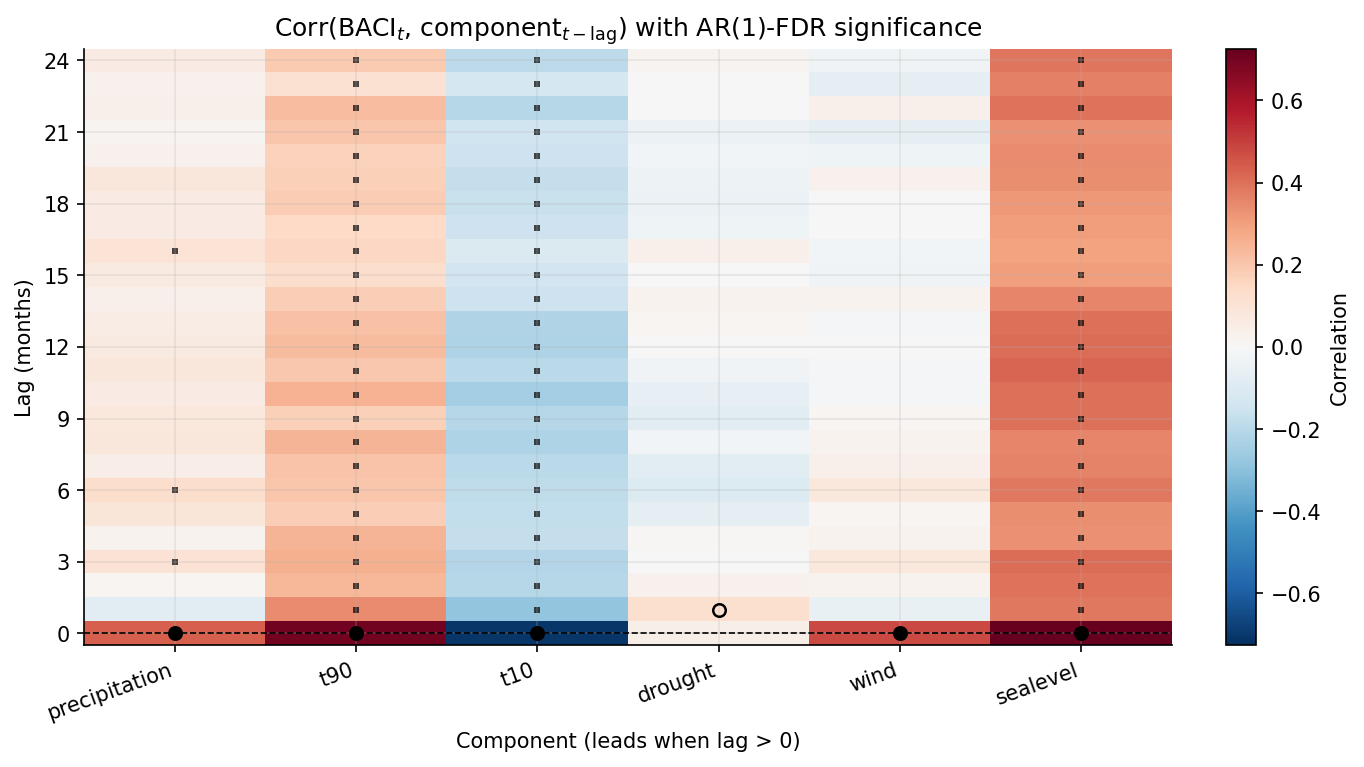

🖼️ Saved significance-aware lag heatmap → ACI-Python/data/composites/BACI_lagged_xcorr_signif.png

⭐ Best lag (with AR(1)-FDR significance):
    component  best_lag_months  corr_at_best  p_value  significant_FDR
precipitation                0         0.433    0.000             True
          t90                0         0.698    0.000             True
          t10                0        -0.707    0.000             True
      drought                1         0.117    0.004            False
         wind                0         0.478    0.000             True
     sealevel                0         0.726    0.000             True
✅ fingerprint matches previous run.

⏱️ Run time: 2.99 s


In [8]:
# baci_analysis_plus_no_csv.py
# All-in-one BACI analysis (no CSV files written):
# - dtype-safe decade bootstrap + CIs
# - rolling trends, change-point (Pettitt), serial dependence
# - standardized OLS weights (ref & post-1990) + optional HAC-robust SEs
# - leave-one-out, permutation importance (sorted)
# - lagged cross-corr + AR(1)- & FDR-aware significance heatmap
# - stable VIF via corr-inverse
# - Shapley/LMG (stable) + signed shares + figure
# - summary JSON + fingerprint JSON
#
# Outputs: PNG figures + JSON summaries only.

import os, time, json
from typing import Dict, Tuple
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# Optional SciPy (Theil–Sen). Falls back to numpy if missing.
try:
    from scipy import stats
    HAVE_SCIPY = True
except Exception:
    HAVE_SCIPY = False

# Optional statsmodels for HAC-robust SEs
try:
    import statsmodels.api as sm
    HAVE_SM = True
except Exception:
    HAVE_SM = False

t0 = time.perf_counter()

# ── Config ────────────────────────────────────────────────────────────────
dir_path = "ACI-Python/data/composites"
paths: Dict[str, str] = {
    "precipitation": os.path.join(dir_path, "precipitation_index.nc"),
    "t90":           os.path.join(dir_path, "t90_index.nc"),
    "t10":           os.path.join(dir_path, "t10_index.nc"),
    "drought":       os.path.join(dir_path, "drought_index.nc"),
    "wind":          os.path.join(dir_path, "wind_index.nc"),
    "sealevel":      os.path.join(dir_path, "sealevel_index.nc"),
}

REF = ("1961-01-31", "1990-12-31")
SEALEVEL_WEIGHT = 1.0
DROUGHT_IS_SPI  = False
ROLL_WIN_MONTHS = 120  # 10-year rolling mean & slopes
ROLL_COEF_WIN   = 180  # 15-year rolling OLS weights

# Fixed monthly grid
full_idx = pd.period_range("1961-01", "2024-12", freq="M").to_timestamp("M")

# ── Helpers ───────────────────────────────────────────────────────────────
def _collapse_to_series(da: xr.DataArray, name: str) -> pd.Series:
    time_dim = "time" if "time" in da.dims else da.dims[0]
    other_dims = [d for d in da.dims if d != time_dim]
    if other_dims:
        da = da.mean(dim=other_dims, skipna=True)
    s = da.to_series()
    s.index = pd.to_datetime(s.index).to_period("M").to_timestamp("M")
    s = s.reindex(full_idx)
    s.name = name
    return s

def load_component_series(name: str, path: str) -> pd.Series:
    if name == "sealevel":
        ds = xr.open_dataset(path)
        da = ds.to_array().mean(dim="variable", skipna=True)
    else:
        try:
            da = xr.open_dataarray(path)
        except Exception:
            ds = xr.open_dataset(path)
            da = ds[name] if name in ds.data_vars else next(iter(ds.data_vars.values()))
    if "step" in da.dims:
        da = da.mean(dim="step")
    if "time" in da.coords:
        da = da.sel(time=slice("1961-01-01", None))
    return _collapse_to_series(da, name)

def build_baci(df: pd.DataFrame, sealevel_weight: float) -> pd.Series:
    return (
        df["t90"] - df["t10"]
        + df["precipitation"]
        + df["drought"]
        + sealevel_weight * df["sealevel"]
        + df["wind"]
    ) / 6.0

def _theil_sen(y: pd.Series) -> Tuple[float, float]:
    x = y.index.year + (y.index.dayofyear - 0.5) / 365.25
    if HAVE_SCIPY:
        slope, intercept, _, _ = stats.theilslopes(y.values, x)
    else:
        dx = x[:, None] - x[None, :]
        dy = y.values[:, None] - y.values[None, :]
        mask = np.triu(np.ones_like(dx, dtype=bool), 1) & (dx != 0)
        slopes = (dy[mask] / dx[mask])
        slope = np.median(slopes)
        intercept = np.median(y.values - slope * x)
    return float(slope), float(intercept)

def durbin_watson(y: pd.Series) -> float:
    num = np.nansum((np.diff(y.values))**2)
    den = np.nansum((y.values - np.nanmean(y.values))**2)
    return float(num/den) if den > 0 else np.nan

def pettitt_test(y: pd.Series) -> Tuple[int, float]:
    r = y.rank()
    n = len(r)
    U = [ (2*np.sum(r[:t]) - t*(n+1)) for t in range(1, n+1) ]
    K = int(np.argmax(np.abs(U)))
    Uk = abs(U[K])
    p = 2*np.exp( (-6*Uk**2) / (n**3 + n**2) )
    return K, float(min(1.0, p))

def acf(y: pd.Series, nlags=24) -> np.ndarray:
    y = y.values - np.nanmean(y.values)
    ac = np.correlate(y, y, mode='full')
    ac = ac[ac.size//2:]
    ac /= ac[0]
    return ac[:nlags+1]

# Block bootstrap CIs for decadal means (dtype-safe)
def block_bootstrap_means(y: pd.Series, decades: pd.Series, B=2000, block=12, random_state=0):
    rng = np.random.default_rng(random_state)
    values = y.values
    n = len(values)
    uniq = np.sort(np.unique(decades.astype(int).values)).tolist()

    def resample_idx():
        idx = []
        while len(idx) < n:
            start = rng.integers(0, n)
            blk = [(start + k) % n for k in range(block)]
            idx.extend(blk)
        return np.array(idx[:n])

    out = {int(d): [] for d in uniq}
    dec_arr = decades.astype(int).values

    for _ in range(B):
        ii = resample_idx()
        dfb = pd.DataFrame({"d": dec_arr[ii], "y": values[ii]})
        m = dfb.groupby("d", sort=False)["y"].mean()
        m.index = m.index.astype(int)
        m = m.reindex(uniq)
        for d in uniq:
            out[d].append(m.loc[d])

    ci = {}
    for d, vals in out.items():
        arr = np.asarray(vals, dtype=float)
        lo = float(np.nanpercentile(arr, 2.5)) if np.isfinite(arr).any() else np.nan
        hi = float(np.nanpercentile(arr, 97.5)) if np.isfinite(arr).any() else np.nan
        ci[d] = (lo, hi)
    return ci

def lagged_cross_corr(df: pd.DataFrame, max_lag=24) -> pd.DataFrame:
    out = {}
    y = df["BACI"]
    for col in ["precipitation","t90","t10","drought","wind","sealevel"]:
        v = df[col]
        vals = []
        for k in range(max_lag+1):
            vals.append(y.corr(v.shift(k)))
        out[col] = vals
    return pd.DataFrame(out, index=pd.Index(range(0, max_lag+1), name="lag"))

# Stable VIF via correlation inverse
def VIF_stable(X: pd.DataFrame, eps: float = 1e-12, ridge: float = 1e-10) -> pd.Series:
    X = X.copy()
    std = X.std(ddof=0)
    zero_var_mask = std < eps
    vifs = pd.Series(index=X.columns, dtype=float)
    if zero_var_mask.any():
        vifs.loc[zero_var_mask.index[zero_var_mask]] = np.inf
        X = X.loc[:, ~zero_var_mask]
    if X.shape[1] == 0:
        return vifs
    Xz = (X - X.mean()) / X.std(ddof=0)
    R = np.corrcoef(Xz.values, rowvar=False)
    R = R + ridge * np.eye(R.shape[0])
    Rinv = np.linalg.pinv(R)
    vifs.loc[X.columns] = np.diag(Rinv)
    return vifs

# Shapley/LMG using correlations (stable)
def R2_corr(Xm: pd.DataFrame, yv: pd.Series, ridge: float = 1e-8) -> float:
    p = Xm.shape[1]
    if p == 0:
        return 0.0
    R = np.corrcoef(Xm.values, rowvar=False)
    if not np.isfinite(R).all():
        return 0.0
    c = np.array([np.corrcoef(Xm.values[:, j], yv.values)[0, 1] for j in range(p)])
    R = R + ridge * np.eye(p)
    try:
        Rinvc = np.linalg.solve(R, c)
    except np.linalg.LinAlgError:
        Rinvc = np.linalg.pinv(R) @ c
    r2 = float(c @ Rinvc)
    if not np.isfinite(r2):
        return 0.0
    return max(0.0, min(1.0, r2))

# ── Load & align ──────────────────────────────────────────────────────────
comp = {k: load_component_series(k, p) for k, p in paths.items()}
df = pd.DataFrame(comp, index=full_idx)
if DROUGHT_IS_SPI:
    df["drought"] = -df["drought"]

# Sanity guards
nan_counts = df.isna().sum()
if nan_counts.sum() != 0:
    raise RuntimeError(f"Unexpected NaNs:\n{nan_counts}")
counts_by_month = pd.Series(df.index.month).value_counts().sort_index()
if not (counts_by_month == counts_by_month.iloc[0]).all():
    raise RuntimeError(f"Unexpected monthly coverage:\n{counts_by_month}")

# Reference-period standardization check
ref = df.loc[pd.to_datetime(REF[0]):pd.to_datetime(REF[1]),
             ["precipitation","t90","t10","drought","wind","sealevel"]]
ref_chk = ref.agg(["mean","std"])
print("\n📏 Reference-period (1961–1990) sanity check (mean≈0, std≈1):")
print(ref_chk.round(3).to_string())

# BACI
df["BACI"] = build_baci(df, SEALEVEL_WEIGHT)

# Basic stats
print("\nBACI composite calculated successfully! 📊 Stats summary:")
print(f"min:  {df['BACI'].min():.3f}")
print(f"max:  {df['BACI'].max():.3f}")
print(f"mean: {df['BACI'].mean():.3f}")
print(f"std:  {df['BACI'].std():.3f}")

# Correlations
corr = df.dropna().corr()
print("\n🔗 Correlation matrix between composites:")
print(corr.round(3).to_string())

# Component–BACI correlations
contrib = corr["BACI"].drop("BACI").sort_values(ascending=False)
print("\n📈 Component–BACI correlations (proxy for contribution):")
print(contrib.round(3).to_string())

# ── Decadal means (+ block-bootstrap CI) — dtype-safe decades ─────────────
decade = pd.Series((df.index.year // 10) * 10, index=df.index, dtype=int, name="decade")
dec_means = df.groupby(decade)["BACI"].mean().to_frame("BACI_mean")
cis = block_bootstrap_means(df["BACI"], decade, B=2000, block=12, random_state=42)
dec_means.index = dec_means.index.astype(int)
dec_means["lo95"] = [cis[int(d)][0] for d in dec_means.index]
dec_means["hi95"] = [cis[int(d)][1] for d in dec_means.index]
print("\n🗓️ Decadal BACI means (95% block-bootstrap CI):")
print(dec_means.round(3).to_string())

# Rolling trends (10-year window) — OLS & Theil–Sen slopes (per year)
win = ROLL_WIN_MONTHS
roll = df["BACI"].rolling(win, center=True).mean()
ols_slopes, ts_slopes, times = [], [], []
for i in range(win//2, len(df)-win//2):
    ys = df["BACI"].iloc[i-win//2:i+win//2]
    xs = ys.index.year + (ys.index.dayofyear - 0.5) / 365.25
    A = np.vstack([xs, np.ones_like(xs)]).T
    beta, _, _, _ = np.linalg.lstsq(A, ys.values, rcond=None)
    ols_slopes.append(beta[0])
    ts_slopes.append(_theil_sen(ys)[0])
    times.append(df.index[i])
trend_df = pd.DataFrame({"OLS_slope_per_year": ols_slopes,
                         "TS_slope_per_year": ts_slopes},
                        index=pd.to_datetime(times))

# Serial dependence
rho1 = float(acf(df["BACI"], nlags=1)[1])
dw   = durbin_watson(df["BACI"])
print(f"\n🔁 Serial dependence: lag-1 ACF = {rho1:.3f} ; Durbin–Watson = {dw:.3f}")

# Pettitt change-point
cp_idx, pval = pettitt_test(df["BACI"])
cp_time = df.index[cp_idx]
print(f"\n🔀 Pettitt change-point: {cp_time.date()} (p ≈ {pval:.4f})")

# Standardized OLS weights (ref & post-1990)
Xref = ref.copy()
Yref = build_baci(ref.assign(BACI=0), SEALEVEL_WEIGHT)
Xz = (Xref - Xref.mean()) / Xref.std(ddof=0)
Yz = (Yref - Yref.mean()) / Yref.std(ddof=0)
B_ref, _, _, _ = np.linalg.lstsq(Xz.values, Yz.values, rcond=None)
weights_ref_std = pd.Series(B_ref, index=Xref.columns).sort_values(ascending=False)
print("\n⚖️ Reference-period standardized OLS weights (elasticities):")
print(weights_ref_std.round(3).to_string())
if weights_ref_std.abs().std() < 0.02:
    print("⚠️  Note: REF weights are ~equal; expected since Y is built from X on the same window.")

post = df.loc[pd.to_datetime("1991-01-31"):, ["precipitation","t90","t10","drought","wind","sealevel","BACI"]]
Xp, Yp = post.drop(columns="BACI"), post["BACI"]
Xpz = (Xp - Xp.mean())/Xp.std(ddof=0)
Ypz = (Yp - Yp.mean())/Yp.std(ddof=0)
B_post, _, _, _ = np.linalg.lstsq(np.c_[Xpz.values, np.ones(len(Xpz))], Ypz.values, rcond=None)
weights_post_std = pd.Series(B_post[:-1], index=Xp.columns).sort_values(ascending=False)
print("\n🧭 Post-1990 standardized OLS weights:")
print(weights_post_std.round(3).to_string())

# HAC-robust SEs (optional)
if HAVE_SM:
    def std_ols_HAC(X: pd.DataFrame, y: pd.Series, lags:int=12):
        Xz = (X - X.mean())/X.std(ddof=0); Yz = (y - y.mean())/y.std(ddof=0)
        Xz = sm.add_constant(Xz)
        model = sm.OLS(Yz, Xz, hasconst=True).fit(cov_type="HAC", cov_kwds={"maxlags": lags})
        coefs = model.params.drop("const")
        ses   = model.bse.drop("const")
        return pd.DataFrame({"coef":coefs, "se_HAC":ses, "t_HAC":coefs/ses}).sort_values("coef", ascending=False)
    ref_hac  = std_ols_HAC(Xref, Yref, lags=12)
    post_hac = std_ols_HAC(Xp, Yp,   lags=12)
    print("\n(ref) HAC-robust standardized OLS:")
    print(ref_hac.round(3).to_string())
    print("\n(post-1990) HAC-robust standardized OLS:")
    print(post_hac.round(3).to_string())
else:
    print("ℹ️ statsmodels not available; skipping HAC-robust SEs.")

# Leave-one-out influence
cols = ["precipitation","t90","t10","drought","wind","sealevel"]
influ = {}
for col in cols:
    tmp = df.copy()
    tmp[col] = 0.0
    baci_loo = build_baci(tmp, SEALEVEL_WEIGHT)
    influ[col] = {
        "corr_with_full": baci_loo.corr(df["BACI"]),
        "std_ratio": baci_loo.std() / df["BACI"].std()
    }
influence_df = pd.DataFrame(influ).T.sort_values("corr_with_full", ascending=False)
print("\n🧪 Leave-one-out influence on BACI:")
print(influence_df.round(3).to_string())

# Permutation importance (sort by impact)
perm = {}
for col in cols:
    shuffled = df[col].sample(frac=1.0, replace=False, random_state=0).reset_index(drop=True)
    shuffled.index = df.index
    tmp = df.copy()
    tmp[col] = shuffled
    baci_perm = build_baci(tmp, SEALEVEL_WEIGHT)
    perm[col] = {
        "corr_with_full": baci_perm.corr(df["BACI"]),
        "rmse_vs_full": float(np.sqrt(np.mean((baci_perm.values - df["BACI"].values)**2)))
    }
perm_df = pd.DataFrame(perm).T
perm_df["importance_corr"] = 1 - perm_df["corr_with_full"]
perm_df = perm_df.sort_values(["importance_corr", "rmse_vs_full"], ascending=[False, False])
print("\n🔀 Permutation importance (most impactful first):")
print(perm_df.round(3).to_string())

# Lagged cross-correlations (0..24 months) + best lag summary
lag_cc = lagged_cross_corr(df, max_lag=24)
best = []
for col in lag_cc.columns:
    lag = int(lag_cc[col].abs().idxmax())
    best.append({"component": col, "best_lag_months": lag, "corr_at_best": float(lag_cc[col].loc[lag])})
lag_best_df = pd.DataFrame(best).sort_values("corr_at_best", ascending=False)
print("\n⏩ Best lag per component (by |corr|):")
print(lag_best_df.round(3).to_string(index=False))

# VIF (stable)
vif_series = VIF_stable(df[cols])
print("\n📐 VIF (stable):")
print(vif_series.round(3).to_string())

# ── Shapley/LMG (stable) + R² check + signed shares & bar figure ──────────
import itertools
X_post = Xp.copy()
Xz_post = (X_post - X_post.mean()) / X_post.std(ddof=0)
yz_post = (Yp - Yp.mean()) / Yp.std(ddof=0)
Xz_post = Xz_post.replace([np.inf, -np.inf], np.nan)
yz_post = yz_post.replace([np.inf, -np.inf], np.nan)
Xz_post, yz_post = Xz_post.align(yz_post.dropna(), join="inner", axis=0)
Xz_post = Xz_post.dropna(axis=0)

contrib_sh = {c: 0.0 for c in cols}
perms = list(itertools.permutations(cols))
for perm in perms:
    S = []
    for var in perm:
        r2_S  = R2_corr(Xz_post.loc[:, S], yz_post) if S else 0.0
        r2_Sv = R2_corr(Xz_post.loc[:, S + [var]], yz_post)
        contrib_sh[var] += (r2_Sv - r2_S)
        S.append(var)
shapley = pd.Series({k: v/len(perms) for k, v in contrib_sh.items()}).sort_values(ascending=False)
R2_total = R2_corr(Xz_post, yz_post)

print(f"\n🧮 Shapley/LMG (post-1990, standardized, stable):")
print(shapley.round(4).to_string())
print(f"Total R^2: {R2_total:.4f} ; Sum Shapley: {shapley.sum():.4f}")

# Signed Shapley using sign of post-1990 standardized OLS weights
coef_sign = np.sign(weights_post_std.reindex(cols))
corr_sign = np.sign(df[cols].corrwith(df["BACI"]))
coef_sign = coef_sign.fillna(corr_sign)
shapley_signed = (shapley.reindex(cols) * coef_sign.reindex(cols)).dropna()

# ── Publication-style combined figure (levels + rolling trend) ────────────
import matplotlib.dates as mdates
outdir = dir_path

REF_START = pd.to_datetime(REF[0])
REF_END   = pd.to_datetime(REF[1])
XMIN, XMAX = df.index.min(), df.index.max()
W0, W1 = trend_df.index.min(), trend_df.index.max()

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

fig = plt.figure(figsize=(12, 7), constrained_layout=True)
gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[2.4, 1.6])
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)

# Top: BACI monthly + 10-year rolling mean
ax1.plot(df.index, df["BACI"], lw=0.7, alpha=0.35, label="BACI monthly", zorder=1)
ax1.plot(roll.index, roll.values, lw=2.2, label="10-yr rolling mean", zorder=2)
ax1.axhline(0, color="black", ls="--", lw=0.8, zorder=0)
ax1.axvspan(REF_START, REF_END, color="0.92", zorder=0, label="Ref. 1961–1990")
ax1.axvline(cp_time, color="tab:red", lw=1.4, ls="-", zorder=3, label=f"Pettitt: {cp_time.date()}")
ax1.set_title("BACI monthly + 10-year rolling mean")
ax1.set_ylabel("BACI (z-score)")
ax1.legend(loc="upper left", frameon=False)

# Bottom: rolling trend slopes
ax2.plot(trend_df.index, trend_df["OLS_slope_per_year"], lw=1.6, label="OLS slope / year")
ax2.plot(trend_df.index, trend_df["TS_slope_per_year"],  lw=1.6, label="TS slope / year")
ax2.axhline(0, color="black", ls="--", lw=0.8)
ax2.axvspan(REF_START, REF_END, color="0.92", zorder=0)
ax2.axvline(cp_time, color="tab:red", lw=1.4, ls="-", zorder=3)
ax2.axvspan(XMIN, W0, facecolor="none", edgecolor="0.7", hatch="//", lw=0, zorder=0)
ax2.axvspan(W1, XMAX, facecolor="none", edgecolor="0.7", hatch="//", lw=0, zorder=0)
ax2.set_title("BACI rolling trend (window=120 months) — slope per year")
ax2.set_ylabel("Slope (per year)")
ax2.legend(loc="upper left", frameon=False)

# Shared x formatting
ax2.set_xlim(XMIN, XMAX)
ax2.xaxis.set_major_locator(mdates.YearLocator(10))
ax2.xaxis.set_minor_locator(mdates.YearLocator(5))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

for ax in (ax1, ax2):
    y0, y1 = ax.get_ylim()
    ax.set_ylim(y0 - 0.05*(y1-y0), y1 + 0.05*(y1-y0))

combined_path = os.path.join(outdir, "BACI_levels_and_trends_combined.png")
fig.savefig(combined_path, bbox_inches="tight")
plt.show()
print(f"🖼️ Saved combined figure → {combined_path}")

# Decadal plot with CI
fig, ax = plt.subplots(figsize=(8, 4.5))
y = dec_means["BACI_mean"]
yerr = np.vstack([y - dec_means["lo95"], dec_means["hi95"] - y])
y.plot(kind="bar", ax=ax, yerr=yerr, capsize=3)
ax.set_title("BACI — Decadal Mean (with 95% block-bootstrap CI)")
ax.set_ylabel("BACI (z-score)")
ax.set_xlabel("Decade")
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.tight_layout()
fig.savefig(os.path.join(outdir, "BACI_decadal_means_CI.png"), dpi=300, bbox_inches="tight")
plt.show()

# Shapley signed bar
fig, ax = plt.subplots(figsize=(7, 3.2))
signed_pct = (shapley_signed * 100).reindex(cols)
ax.bar(signed_pct.index, signed_pct.values)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("Shapley share of R² (%)")
ax.set_title("BACI (post-1990): Shapley/LMG variance shares (signed)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
fig.savefig(os.path.join(outdir, "BACI_shapley_signed_bar.png"), dpi=300, bbox_inches="tight")
plt.show()

# ── Lagged xcorr heatmap with AR(1)-adjusted significance & BH/FDR ────────
from matplotlib.colors import TwoSlopeNorm
from math import atanh, erf, sqrt

M = lag_cc.values
lags = lag_cc.index.values
comps = lag_cc.columns.tolist()
T = len(df)

def lag1_acf(s: pd.Series) -> float:
    v = s.values
    v = v - np.nanmean(v)
    num = np.nansum(v[1:] * v[:-1])
    den = np.nansum(v * v)
    return float(num/den) if den > 0 else 0.0

r1_y = lag1_acf(df["BACI"])
r1_x = {c: lag1_acf(df[c]) for c in comps}

def neff(N, r1x, r1y):
    num = (1 - r1x * r1y)
    den = (1 + r1x * r1y)
    val = N * (num / den) if den != 0 else N
    return max(3.0, float(val))

def p_two_sided_from_r(r, Neff):
    r = max(min(r, 0.999999), -0.999999)
    z = abs(atanh(r)) * sqrt(max(1.0, Neff - 3.0))
    p = 2.0 * 0.5 * (1.0 - erf(z / sqrt(2.0)))
    return float(min(1.0, max(0.0, p)))

pvals = np.full_like(M, np.nan, dtype=float)
sig = np.zeros_like(M, dtype=bool)
alpha = 0.05

for j, c in enumerate(comps):
    pj = []
    for i, k in enumerate(lags):
        Nlag = T - k
        Ne = neff(Nlag, r1_x[c], r1_y)
        pj.append(p_two_sided_from_r(M[i, j], Ne))
    pj = np.array(pj)
    pvals[:, j] = pj

    # Benjamini–Hochberg across lags per component
    m = len(pj)
    order = np.argsort(pj)
    thresh = alpha * (np.arange(1, m+1) / m)
    passed = pj[order] <= thresh
    kmax = np.where(passed)[0].max() if passed.any() else -1
    if kmax >= 0:
        sig_mask = np.zeros(m, dtype=bool)
        sig_mask[order[:kmax+1]] = True
        sig[:, j] = sig_mask

# Plot heatmap
maxabs = np.nanmax(np.abs(M))
norm = TwoSlopeNorm(vmin=-maxabs, vcenter=0.0, vmax=maxabs)
fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
extent = [-0.5, len(comps)-0.5, lags.min()-0.5, lags.max()+0.5]
im = ax.imshow(M, aspect="auto", origin="lower", extent=extent,
               interpolation="nearest", cmap="RdBu_r", norm=norm)
ax.axhline(0, color="black", lw=0.8, ls="--")

# best-lag markers
for j, c in enumerate(comps):
    k = int(np.nanargmax(np.abs(M[:, j])))
    is_sig = bool(sig[k, j])
    ax.plot(j, lags[k],
            marker="o", ms=6,
            mfc=("k" if is_sig else "none"), mec="k", mew=1.2)

# small squares for all significant cells
yy, xx = np.where(sig)
ax.scatter(xx, lags[yy], s=10, c="k", marker="s", lw=0, alpha=0.7)

ax.set_title(r"Corr(BACI$_t$, component$_{t-\mathrm{lag}}$) with AR(1)-FDR significance")
ax.set_xlabel("Component (leads when lag > 0)")
ax.set_ylabel("Lag (months)")
ax.set_xticks(range(len(comps)))
ax.set_xticklabels(comps, rotation=20, ha="right")
step = 3 if lags.max() <= 24 else 6
ax.set_yticks(np.arange(lags.min(), lags.max()+1, step))
cbar = fig.colorbar(im, ax=ax); cbar.set_label("Correlation")
for spine in ("top", "right"): ax.spines[spine].set_visible(False)

heatmap_path = os.path.join(outdir, "BACI_lagged_xcorr_signif.png")
fig.savefig(heatmap_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"🖼️ Saved significance-aware lag heatmap → {heatmap_path}")

# Console table: best lag + significance
best_rows = []
for j, c in enumerate(comps):
    k = int(np.nanargmax(np.abs(M[:, j])))
    best_rows.append({
        "component": c,
        "best_lag_months": int(lags[k]),
        "corr_at_best": float(M[k, j]),
        "p_value": float(pvals[k, j]),
        "significant_FDR": bool(sig[k, j])
    })
print("\n⭐ Best lag (with AR(1)-FDR significance):")
print(pd.DataFrame(best_rows).to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# ── JSON summary + fingerprint (no CSVs) ──────────────────────────────────
summary = {
    "acf_lag1": rho1,
    "durbin_watson": dw,
    "pettitt_cp_date": str(cp_time.date()),
    "pettitt_p": pval,
    "component_BACI_corr": contrib.round(6).to_dict(),
    "ref_std_OLS_weights": weights_ref_std.round(6).to_dict(),
    "post1990_std_OLS_weights": weights_post_std.round(6).to_dict(),
    "R2_total_post1990_std": round(float(R2_total), 6),
}
with open(os.path.join(dir_path, "BACI_analysis_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

fp = {
    "mean": float(df["BACI"].mean()),
    "std":  float(df["BACI"].std()),
    "head": df["BACI"].head(3).round(6).tolist(),
    "tail": df["BACI"].tail(3).round(6).tolist(),
}
fp_path = os.path.join(dir_path, "BACI_fingerprint.json")
if os.path.exists(fp_path):
    with open(fp_path) as f:
        prev = json.load(f)
    eq = (
        abs(prev.get("mean", np.nan) - fp["mean"]) < 1e-6 and
        abs(prev.get("std",  np.nan) - fp["std"])  < 1e-6 and
        prev.get("head") == fp["head"] and
        prev.get("tail") == fp["tail"]
    )
    print("✅ fingerprint matches previous run." if eq else "⚠️ fingerprint changed since last run!")
else:
    with open(fp_path, "w") as f:
        json.dump(fp, f, indent=2)
    print("ℹ️ First run — fingerprint saved.")

print(f"\n⏱️ Run time: {time.perf_counter() - t0:.2f} s")
